# FIFA World Cup 2026 ML Simulator

This notebook builds an end-to-end machine learning simulator for the 2026 FIFA World Cup. The goal is to estimate each team’s probability of advancing through the tournament and winning the title using historical match results, modern team-strength indicators, and the official 2026 tournament structure.

The project combines a match-result prediction model with a Monte Carlo tournament simulation. The model is trained on recent international football matches and uses features such as FIFA ranking, Elo rating, recent form, match context, and squad-strength indicators derived from FC26 player data. After predicting match probabilities, the notebook simulates the group stage, applies qualification rules, and runs the knockout stage using the real 2026 bracket format.

What this notebook includes:

* Cleans and prepares international match, ranking, Elo, squad, and fixture datasets.
* Trains and evaluates a modern win/draw/loss classifier using 2018+ international matches.
* Builds 2026 team-strength scores using FIFA rank, Elo, recent form, and FC26 squad features.
* Simulates the official 2026 group-stage format with 12 groups of four teams.
* Advances the top two teams from each group plus the eight best third-place teams.
* Applies third-place ranking rules using points, goal difference, goals scored, and ranking-based fallback.
* Uses Annex C third-place mappings to place qualifying third-place teams into the Round of 32.
* Simulates the real knockout-stage route from the Round of 32 through the final.
* Produces winner probabilities, stage probabilities, group fixture predictions, and visual outputs.

This is an initial real-bracket baseline model. It is not intended to be a perfect prediction system, but rather an initial, reproducible sports analytics project that reflects my development as a machine learning student and demonstrates how data cleaning, feature engineering, model training, and tournament simulation can be combined to forecast a major international competition.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import unicodedata
import re
import matplotlib.pyplot as plt
from collections import deque, defaultdict
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

## 2. Auto-detect Kaggle input files

In [2]:
INPUT_DIR = Path("/kaggle/input")

print("CSV files detected:")
for p in INPUT_DIR.rglob("*.csv"):
    print(p)

def find_dir_contains(name_part):
    name_part = name_part.lower()
    for p in INPUT_DIR.rglob("*"):
        if p.is_dir() and name_part in p.name.lower():
            return p
    return None

def find_csv_exact(filename, avoid_substrings=None):
    avoid_substrings = avoid_substrings or []
    matches = []
    for p in INPUT_DIR.rglob(filename):
        p_str = str(p).lower()
        if any(a.lower() in p_str for a in avoid_substrings):
            continue
        matches.append(p)
    return matches[0] if matches else None

BASE_PATH = find_dir_contains("world-cup-26-dataset")
if BASE_PATH is None:
    BASE_PATH = Path("/kaggle/input/datasets/saiaathishkarthik/world-cup-26-dataset")

MATCHES_PATH = BASE_PATH / "archive (1)" / "results.csv"
RANKINGS_PATH = BASE_PATH / "archive (2)" / "fifa_ranking.csv"
TEAM_FEATURES_2026_PATH = BASE_PATH / "team_squad_features_2026.csv"
GROUP_FIXTURES_2026_PATH = BASE_PATH / "group_stage_fixtures_2026.csv"

THIRD_PLACE_ANNEX_PATH = BASE_PATH / "third_place_annex_c_2026.csv"
THIRD_PLACE_SLOTS_PATH = BASE_PATH / "third_place_slots_2026.csv"
KNOCKOUT_BRACKET_PATH = BASE_PATH / "knockout_bracket_2026.csv"

ELO_PATH = None
for p in INPUT_DIR.rglob("eloratings.csv"):
    if "world-cup-26-dataset" not in str(p).lower():
        ELO_PATH = p
        break
if ELO_PATH is None:
    ELO_PATH = BASE_PATH / "archive (3)" / "eloratings.csv"

ODDS_PATH = find_csv_exact("Matches_Odds.csv")
ODDS_RESULTS_PATH = find_csv_exact("Matches_Results.csv")

WC_2026_FIXTURES_EXTRA = find_csv_exact("wc_2026_fixtures.csv")
WC_2026_TEAMS_EXTRA = find_csv_exact("wc_2026_teams.csv")

paths = {
    "BASE_PATH": BASE_PATH,
    "MATCHES_PATH": MATCHES_PATH,
    "RANKINGS_PATH": RANKINGS_PATH,
    "TEAM_FEATURES_2026_PATH": TEAM_FEATURES_2026_PATH,
    "GROUP_FIXTURES_2026_PATH": GROUP_FIXTURES_2026_PATH,
    "THIRD_PLACE_ANNEX_PATH": THIRD_PLACE_ANNEX_PATH,
    "THIRD_PLACE_SLOTS_PATH": THIRD_PLACE_SLOTS_PATH,
    "KNOCKOUT_BRACKET_PATH": KNOCKOUT_BRACKET_PATH,
    "ELO_PATH": ELO_PATH,
    "ODDS_PATH": ODDS_PATH,
    "ODDS_RESULTS_PATH": ODDS_RESULTS_PATH,
    "WC_2026_FIXTURES_EXTRA": WC_2026_FIXTURES_EXTRA,
    "WC_2026_TEAMS_EXTRA": WC_2026_TEAMS_EXTRA,
}

print("\\nImportant paths:")
for k, v in paths.items():
    exists = v.exists() if isinstance(v, Path) else False
    print(f"{k}: {v} | exists={exists}")

CSV files detected:
/kaggle/input/datasets/eladsil/football-games-odds/Matches_Odds.csv
/kaggle/input/datasets/eladsil/football-games-odds/Matches_Results.csv
/kaggle/input/datasets/saifalnimri/international-football-elo-ratings/eloratings.csv
/kaggle/input/datasets/kulkarniparth09/fifa-world-cup-complete-dataset-19302026/wc_all_matches.csv
/kaggle/input/datasets/kulkarniparth09/fifa-world-cup-complete-dataset-19302026/wc_2026_fixtures.csv
/kaggle/input/datasets/kulkarniparth09/fifa-world-cup-complete-dataset-19302026/wc_top_scorers.csv
/kaggle/input/datasets/kulkarniparth09/fifa-world-cup-complete-dataset-19302026/wc_all_editions.csv
/kaggle/input/datasets/kulkarniparth09/fifa-world-cup-complete-dataset-19302026/wc_2026_teams.csv
/kaggle/input/datasets/saiaathishkarthik/world-cup-26-dataset/fc26_unmatched_players.csv
/kaggle/input/datasets/saiaathishkarthik/world-cup-26-dataset/low_confidence_matches.csv
/kaggle/input/datasets/saiaathishkarthik/world-cup-26-dataset/third_place_annex_c

## 3. Load datasets

In [3]:
matches = pd.read_csv(MATCHES_PATH)
rankings = pd.read_csv(RANKINGS_PATH)
team_features_2026 = pd.read_csv(TEAM_FEATURES_2026_PATH)
group_fixtures_2026 = pd.read_csv(GROUP_FIXTURES_2026_PATH)

third_place_annex_raw = pd.read_csv(THIRD_PLACE_ANNEX_PATH) if THIRD_PLACE_ANNEX_PATH.exists() else None
third_place_slots_raw = pd.read_csv(THIRD_PLACE_SLOTS_PATH) if THIRD_PLACE_SLOTS_PATH.exists() else None
knockout_bracket_raw = pd.read_csv(KNOCKOUT_BRACKET_PATH) if KNOCKOUT_BRACKET_PATH.exists() else None

elo_raw = pd.read_csv(ELO_PATH) if ELO_PATH is not None and ELO_PATH.exists() else None
odds_raw = pd.read_csv(ODDS_PATH) if ODDS_PATH is not None and ODDS_PATH.exists() else None
odds_results_raw = pd.read_csv(ODDS_RESULTS_PATH) if ODDS_RESULTS_PATH is not None and ODDS_RESULTS_PATH.exists() else None

wc_2026_fixtures_extra = pd.read_csv(WC_2026_FIXTURES_EXTRA) if WC_2026_FIXTURES_EXTRA is not None and WC_2026_FIXTURES_EXTRA.exists() else None
wc_2026_teams_extra = pd.read_csv(WC_2026_TEAMS_EXTRA) if WC_2026_TEAMS_EXTRA is not None and WC_2026_TEAMS_EXTRA.exists() else None

print("matches:", matches.shape)
print("rankings:", rankings.shape)
print("team_features_2026:", team_features_2026.shape)
print("group_fixtures_2026:", group_fixtures_2026.shape)
print("third_place_annex_raw:", None if third_place_annex_raw is None else third_place_annex_raw.shape)
print("third_place_slots_raw:", None if third_place_slots_raw is None else third_place_slots_raw.shape)
print("knockout_bracket_raw:", None if knockout_bracket_raw is None else knockout_bracket_raw.shape)
print("elo_raw:", None if elo_raw is None else elo_raw.shape)
print("wc_2026_fixtures_extra:", None if wc_2026_fixtures_extra is None else wc_2026_fixtures_extra.shape)
print("wc_2026_teams_extra:", None if wc_2026_teams_extra is None else wc_2026_teams_extra.shape)

display(team_features_2026.head())
display(group_fixtures_2026.head())

if third_place_annex_raw is not None:
    print("Annex C columns:")
    print(third_place_annex_raw.columns.tolist())
    display(third_place_annex_raw.head())

if knockout_bracket_raw is not None:
    print("Knockout bracket columns:")
    print(knockout_bracket_raw.columns.tolist())
    display(knockout_bracket_raw.head())

matches: (49437, 9)
rankings: (57793, 16)
team_features_2026: (48, 16)
group_fixtures_2026: (72, 25)
third_place_annex_raw: (495, 19)
third_place_slots_raw: (8, 6)
knockout_bracket_raw: (32, 25)
elo_raw: (6678, 4)
wc_2026_fixtures_extra: (104, 15)
wc_2026_teams_extra: (48, 7)


,country,fifa_code,squad_players,fc26_players_matched,player_data_coverage,player_features_available,top_11_avg_overall,top_23_avg_overall,squad_avg_overall,squad_avg_age,avg_pace,avg_shooting,avg_passing,avg_dribbling,avg_defending,avg_physical
0,Algeria,ALG,26,15,0.5769,0,77.818182,75.333333,75.333333,26.733333,72.000000,66.000000,71.066667,77.400000,62.333333,69.266667
1,Argentina,ARG,26,25,0.9615,1,84.636364,81.956522,81.520000,28.760000,74.760000,69.640000,75.960000,70.320000,65.480000,75.240000
2,Australia,AUS,26,21,0.8077,1,70.909091,67.952381,67.952381,26.523810,71.142857,55.571429,59.904762,57.666667,56.190476,71.428571
3,Austria,AUT,26,23,0.8846,1,79.090909,75.826087,75.826087,28.347826,69.739130,60.826087,68.913043,63.782609,64.347826,72.956522
4,Belgium,BEL,26,25,0.9615,1,82.909091,79.652174,78.840000,27.360000,71.200000,66.160000,73.160000,69.040000,60.280000,73.160000


,match_no,stage,round,group,team_a_seed,team_b_seed,team_a_code,team_b_code,team_a,team_b,match_date_local,kickoff_local,kickoff_et_date,kickoff_et,kickoff_utc,venue_common,venue_fifa,city,host_city,host_country,timezone,neutral_site,source_url,official_schedule_url,source_version_date
0,1,Group,Group Stage,A,A1,A2,MEX,RSA,Mexico,South Africa,2026-06-11,13:00,2026-06-11,15:00,2026-06-11T19:00:00Z,Estadio Azteca,Mexico City Stadium,Mexico City,Mexico City,Mexico,America/Mexico_City,0,https://www.fourfourtwo.com/competition/world-...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
1,2,Group,Group Stage,A,A3,A4,KOR,CZE,Korea Republic,Czechia,2026-06-11,20:00,2026-06-11,22:00,2026-06-12T02:00:00Z,Estadio Akron,Guadalajara Stadium,Zapopan,Guadalajara,Mexico,America/Mexico_City,1,https://www.fourfourtwo.com/competition/world-...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
2,3,Group,Group Stage,B,B1,B2,CAN,BIH,Canada,Bosnia And Herzegovina,2026-06-12,15:00,2026-06-12,15:00,2026-06-12T19:00:00Z,BMO Field,Toronto Stadium,Toronto,Toronto,Canada,America/Toronto,0,https://www.fourfourtwo.com/competition/world-...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
3,4,Group,Group Stage,D,D1,D2,USA,PAR,USA,Paraguay,2026-06-12,18:00,2026-06-12,21:00,2026-06-13T01:00:00Z,SoFi Stadium,Los Angeles Stadium,Inglewood,Los Angeles,USA,America/Los_Angeles,0,https://www.fourfourtwo.com/competition/world-...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
4,5,Group,Group Stage,C,C3,C4,HAI,SCO,Haiti,Scotland,2026-06-13,21:00,2026-06-13,21:00,2026-06-14T01:00:00Z,MetLife Stadium,New York New Jersey Stadium,East Rutherford,New York New Jersey,USA,America/New_York,1,https://www.fourfourtwo.com/competition/world-...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10


Annex C columns:
['option', 'qualified_third_groups_key', 'qualified_third_groups', 'slot_1A', 'slot_1B', 'slot_1D', 'slot_1E', 'slot_1G', 'slot_1I', 'slot_1K', 'slot_1L', 'match_79_1A_assignment', 'match_85_1B_assignment', 'match_81_1D_assignment', 'match_74_1E_assignment', 'match_82_1G_assignment', 'match_77_1I_assignment', 'match_87_1K_assignment', 'match_80_1L_assignment']


,option,qualified_third_groups_key,qualified_third_groups,slot_1A,slot_1B,slot_1D,slot_1E,slot_1G,slot_1I,slot_1K,slot_1L,match_79_1A_assignment,match_85_1B_assignment,match_81_1D_assignment,match_74_1E_assignment,match_82_1G_assignment,match_77_1I_assignment,match_87_1K_assignment,match_80_1L_assignment
0,1,EFGHIJKL,"E,F,G,H,I,J,K,L",3E,3J,3I,3F,3H,3G,3L,3K,3E,3J,3I,3F,3H,3G,3L,3K
1,2,DFGHIJKL,"D,F,G,H,I,J,K,L",3H,3G,3I,3D,3J,3F,3L,3K,3H,3G,3I,3D,3J,3F,3L,3K
2,3,DEGHIJKL,"D,E,G,H,I,J,K,L",3E,3J,3I,3D,3H,3G,3L,3K,3E,3J,3I,3D,3H,3G,3L,3K
3,4,DEFHIJKL,"D,E,F,H,I,J,K,L",3E,3J,3I,3D,3H,3F,3L,3K,3E,3J,3I,3D,3H,3F,3L,3K
4,5,DEFGIJKL,"D,E,F,G,I,J,K,L",3E,3G,3I,3D,3J,3F,3L,3K,3E,3G,3I,3D,3J,3F,3L,3K


Knockout bracket columns:
['match_no', 'stage', 'round', 'group', 'team_a_seed', 'team_b_seed', 'team_a_code', 'team_b_code', 'team_a', 'team_b', 'match_date_local', 'kickoff_local', 'kickoff_et_date', 'kickoff_et', 'kickoff_utc', 'venue_common', 'venue_fifa', 'city', 'host_city', 'host_country', 'timezone', 'neutral_site', 'source_url', 'official_schedule_url', 'source_version_date']


,match_no,stage,round,group,team_a_seed,team_b_seed,team_a_code,team_b_code,team_a,team_b,match_date_local,kickoff_local,kickoff_et_date,kickoff_et,kickoff_utc,venue_common,venue_fifa,city,host_city,host_country,timezone,neutral_site,source_url,official_schedule_url,source_version_date
0,73,Round of 32,Round of 32,NaN,2A,2B,NaN,NaN,2A,2B,2026-06-28,12:00,2026-06-28,15:00,2026-06-28T19:00:00Z,SoFi Stadium,Los Angeles Stadium,Inglewood,Los Angeles,USA,America/Los_Angeles,1,https://digitalhub.fifa.com/asset/4b5d4417-334...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
1,74,Round of 32,Round of 32,NaN,1E,3ABCDF,NaN,NaN,1E,3ABCDF,2026-06-29,16:30,2026-06-29,16:30,2026-06-29T20:30:00Z,Gillette Stadium,Boston Stadium,Foxborough,Boston,USA,America/New_York,1,https://digitalhub.fifa.com/asset/4b5d4417-334...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
2,75,Round of 32,Round of 32,NaN,1F,2C,NaN,NaN,1F,2C,2026-06-29,19:00,2026-06-29,21:00,2026-06-30T01:00:00Z,Estadio BBVA,Monterrey Stadium,Guadalupe,Monterrey,Mexico,America/Monterrey,1,https://digitalhub.fifa.com/asset/4b5d4417-334...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
3,76,Round of 32,Round of 32,NaN,1C,2F,NaN,NaN,1C,2F,2026-06-29,12:00,2026-06-29,13:00,2026-06-29T17:00:00Z,NRG Stadium,Houston Stadium,Houston,Houston,USA,America/Chicago,1,https://digitalhub.fifa.com/asset/4b5d4417-334...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10
4,77,Round of 32,Round of 32,NaN,1I,3CDFGH,NaN,NaN,1I,3CDFGH,2026-06-30,17:00,2026-06-30,17:00,2026-06-30T21:00:00Z,MetLife Stadium,New York New Jersey Stadium,East Rutherford,New York New Jersey,USA,America/New_York,1,https://digitalhub.fifa.com/asset/4b5d4417-334...,https://digitalhub.fifa.com/asset/4b5d4417-334...,2026-04-10


## 4. Cleaning helpers

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

TEAM_ALIASES = {
    "usa": "united states",
    "us": "united states",
    "u s a": "united states",
    "united states of america": "united states",
    "korea republic": "south korea",
    "republic of korea": "south korea",
    "ir iran": "iran",
    "iran islamic republic": "iran",
    "turkiye": "turkey",
    "côte d ivoire": "ivory coast",
    "cote d ivoire": "ivory coast",
    "cote divoire": "ivory coast",
    "cabo verde": "cape verde",
    "congo dr": "dr congo",
    "democratic republic of congo": "dr congo",
    "czech republic": "czechia",
    "bosnia herzegovina": "bosnia and herzegovina",
    "bosnia": "bosnia and herzegovina",
    "new zeland": "new zealand",
    "england national team": "england",
    "france national team": "france",
    "germany national team": "germany",
    "brazil national team": "brazil",
    "argentina national team": "argentina",
}

def team_key(name):
    c = clean_text(name)
    return TEAM_ALIASES.get(c, c)

def standardize_column_names(df):
    df = df.copy()
    df.columns = [clean_text(c).replace(" ", "_") for c in df.columns]
    return df

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def parse_date_series(series):
    opts = [
        pd.to_datetime(series, errors="coerce"),
        pd.to_datetime(series, errors="coerce", dayfirst=True),
        pd.to_datetime(series.astype(str), errors="coerce"),
        pd.to_datetime(series.astype(str), errors="coerce", dayfirst=True),
    ]
    counts = [o.notna().sum() for o in opts]
    return opts[int(np.argmax(counts))]

def to_numeric_clean(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.extract(r"([-+]?\d*\.?\d+)")[0],
        errors="coerce"
    )

def minmax_score(series):
    s = pd.to_numeric(series, errors="coerce")
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.5, index=s.index)
    return ((s - mn) / (mx - mn)).fillna(0.5)

def group_letter(value):
    if pd.isna(value):
        return ""
    s = str(value).strip().upper()
    # handle "Group A"
    m = re.search(r"\b([A-L])\b", s)
    if m:
        return m.group(1)
    # handle plain A
    return s[0] if s and s[0] in list("ABCDEFGHIJKL") else s

## 5. Clean historical matches

In [5]:
matches = matches.copy()
matches["date"] = parse_date_series(matches["date"])

matches = matches.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
matches["home_score"] = to_numeric_clean(matches["home_score"]).astype(int)
matches["away_score"] = to_numeric_clean(matches["away_score"]).astype(int)

matches["home_team_clean"] = matches["home_team"].apply(team_key)
matches["away_team_clean"] = matches["away_team"].apply(team_key)

matches = matches.sort_values("date").reset_index(drop=True)

def get_result(row):
    if row["home_score"] > row["away_score"]:
        return 2
    if row["home_score"] == row["away_score"]:
        return 1
    return 0

matches["result"] = matches.apply(get_result, axis=1)
matches["is_neutral"] = matches["neutral"].astype(int)
matches["is_world_cup"] = matches["tournament"].str.contains("FIFA World Cup", case=False, na=False).astype(int)
matches["is_friendly"] = matches["tournament"].str.contains("Friendly", case=False, na=False).astype(int)

print(matches.shape)
display(matches.head())
display(matches["result"].value_counts(normalize=True))

/tmp/ipykernel_23/2438401057.py:57: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pd.to_datetime(series, errors="coerce", dayfirst=True),
/tmp/ipykernel_23/2438401057.py:59: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pd.to_datetime(series.astype(str), errors="coerce", dayfirst=True),


(49365, 15)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_team_clean,away_team_clean,result,is_neutral,is_world_cup,is_friendly
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,scotland,england,1,0,0,1
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,england,scotland,2,0,0,1
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,scotland,england,2,0,0,1
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,england,scotland,1,0,0,1
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,scotland,england,2,0,0,1


result
2    0.490064
0    0.282548
1    0.227388
Name: proportion, dtype: float64

## 6. Rolling recent-form features, 2018-present

In [6]:
def build_recent_team_history_features(df, window=12, start_year=2018):
    df = df.copy()
    df = df[df["date"].dt.year >= start_year].sort_values("date").reset_index(drop=True)

    recent_by_team = {}
    rows = []

    def get_recent(team):
        return recent_by_team.get(team, deque(maxlen=window))

    def stats(team):
        recent = get_recent(team)
        if len(recent) == 0:
            return {
                "matches": 0,
                "win_rate": 0.5,
                "draw_rate": 0.25,
                "avg_goals_for": 1.0,
                "avg_goals_against": 1.0,
                "goal_diff_per_match": 0.0,
            }
        wins = sum(1 for m in recent if m["result"] == "win")
        draws = sum(1 for m in recent if m["result"] == "draw")
        gf = sum(m["goals_for"] for m in recent)
        ga = sum(m["goals_against"] for m in recent)
        n = len(recent)
        return {
            "matches": n,
            "win_rate": wins / n,
            "draw_rate": draws / n,
            "avg_goals_for": gf / n,
            "avg_goals_against": ga / n,
            "goal_diff_per_match": (gf - ga) / n,
        }

    for _, row in df.iterrows():
        home = row["home_team_clean"]
        away = row["away_team_clean"]

        if home not in recent_by_team:
            recent_by_team[home] = deque(maxlen=window)
        if away not in recent_by_team:
            recent_by_team[away] = deque(maxlen=window)

        hs = stats(home)
        as_ = stats(away)

        rows.append({
            "date": row["date"],
            "year": row["date"].year,
            "home_team": row["home_team"],
            "away_team": row["away_team"],
            "home_team_clean": home,
            "away_team_clean": away,
            "tournament": row["tournament"],

            "home_matches_before": hs["matches"],
            "away_matches_before": as_["matches"],
            "matches_before_diff": hs["matches"] - as_["matches"],

            "home_win_rate_before": hs["win_rate"],
            "away_win_rate_before": as_["win_rate"],
            "win_rate_diff": hs["win_rate"] - as_["win_rate"],

            "home_draw_rate_before": hs["draw_rate"],
            "away_draw_rate_before": as_["draw_rate"],
            "draw_rate_diff": hs["draw_rate"] - as_["draw_rate"],

            "home_avg_goals_for_before": hs["avg_goals_for"],
            "away_avg_goals_for_before": as_["avg_goals_for"],
            "avg_goals_for_diff": hs["avg_goals_for"] - as_["avg_goals_for"],

            "home_avg_goals_against_before": hs["avg_goals_against"],
            "away_avg_goals_against_before": as_["avg_goals_against"],
            "avg_goals_against_diff": hs["avg_goals_against"] - as_["avg_goals_against"],

            "home_goal_diff_per_match_before": hs["goal_diff_per_match"],
            "away_goal_diff_per_match_before": as_["goal_diff_per_match"],
            "goal_diff_per_match_diff": hs["goal_diff_per_match"] - as_["goal_diff_per_match"],

            "is_neutral": row["is_neutral"],
            "is_world_cup": row["is_world_cup"],
            "is_friendly": row["is_friendly"],
            "result": row["result"],
        })

        if row["home_score"] > row["away_score"]:
            hr, ar = "win", "loss"
        elif row["home_score"] < row["away_score"]:
            hr, ar = "loss", "win"
        else:
            hr, ar = "draw", "draw"

        recent_by_team[home].append({"result": hr, "goals_for": row["home_score"], "goals_against": row["away_score"]})
        recent_by_team[away].append({"result": ar, "goals_for": row["away_score"], "goals_against": row["home_score"]})

    return pd.DataFrame(rows), recent_by_team

model_df, final_team_recent = build_recent_team_history_features(matches, window=12, start_year=2018)
print(model_df.shape)
display(model_df.head())

(8068, 29)


,date,year,home_team,away_team,home_team_clean,away_team_clean,tournament,home_matches_before,away_matches_before,matches_before_diff,home_win_rate_before,away_win_rate_before,win_rate_diff,home_draw_rate_before,away_draw_rate_before,draw_rate_diff,home_avg_goals_for_before,away_avg_goals_for_before,avg_goals_for_diff,home_avg_goals_against_before,away_avg_goals_against_before,avg_goals_against_diff,home_goal_diff_per_match_before,away_goal_diff_per_match_before,goal_diff_per_match_diff,is_neutral,is_world_cup,is_friendly,result
0,2018-01-02,2018,Iraq,United Arab Emirates,iraq,united arab emirates,Gulf Cup,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0,1
1,2018-01-02,2018,Oman,Bahrain,oman,bahrain,Gulf Cup,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0,2
2,2018-01-05,2018,Oman,United Arab Emirates,oman,united arab emirates,Gulf Cup,1,1,0,1.0,0.0,1.0,0.00,1.00,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1,0,0,1
3,2018-01-07,2018,Estonia,Sweden,estonia,sweden,Friendly,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,1,1
4,2018-01-11,2018,Indonesia,Iceland,indonesia,iceland,Friendly,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0


## 7. Prepare FIFA rankings and Elo

In [7]:
rankings = rankings.copy()
rankings["rank_date"] = parse_date_series(rankings["rank_date"])
rankings["team_clean"] = rankings["country_full"].apply(team_key)
rankings["rank"] = to_numeric_clean(rankings["rank"])
rankings["total_points"] = to_numeric_clean(rankings["total_points"])

rank_ref = rankings[["rank_date", "team_clean", "rank", "total_points"]].dropna(subset=["rank_date", "team_clean", "rank"])
rank_ref = rank_ref.sort_values(["team_clean", "rank_date"]).reset_index(drop=True)

def prepare_elo(elo_df):
    if elo_df is None:
        return pd.DataFrame(columns=["date", "team_clean", "elo"])
    df = standardize_column_names(elo_df)
    print("Elo columns:", df.columns.tolist())

    date_col = pick_col(df, ["date", "rank_date", "match_date"])
    team_col = pick_col(df, ["team", "country", "country_full", "nation", "name"])
    rating_col = pick_col(df, ["elo", "rating", "elorating", "elo_rating"])

    if date_col is None or team_col is None or rating_col is None:
        print("Could not detect Elo columns.")
        return pd.DataFrame(columns=["date", "team_clean", "elo"])

    out = pd.DataFrame({
        "date": parse_date_series(df[date_col]),
        "team_clean": df[team_col].apply(team_key),
        "elo": to_numeric_clean(df[rating_col]),
    })
    out = out.dropna(subset=["date", "team_clean", "elo"]).sort_values(["team_clean", "date"]).reset_index(drop=True)
    return out

elo_ref = prepare_elo(elo_raw)

print("rank_ref:", rank_ref.shape)
print("elo_ref:", elo_ref.shape)
print("Elo unique teams:", elo_ref["team_clean"].nunique())
display(rank_ref.head())
display(elo_ref.head())

Elo columns: ['date', 'team', 'rating', 'change']
rank_ref: (57793, 4)
elo_ref: (44, 3)
Elo unique teams: 4


/tmp/ipykernel_23/2438401057.py:57: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pd.to_datetime(series, errors="coerce", dayfirst=True),
/tmp/ipykernel_23/2438401057.py:59: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pd.to_datetime(series.astype(str), errors="coerce", dayfirst=True),


,rank_date,team_clean,rank,total_points
0,2003-01-15,afghanistan,204,0.0
1,2003-02-19,afghanistan,203,0.0
2,2003-03-26,afghanistan,198,0.0
3,2003-04-23,afghanistan,198,0.0
4,2003-05-21,afghanistan,199,0.0


,date,team_clean,elo
0,1872-11-30,england,2003.0
1,1873-03-08,england,2014.0
2,1874-03-07,england,2006.0
3,1875-03-06,england,2003.0
4,1876-03-04,england,1990.0


## 8. Merge latest FIFA/Elo values before each historical match

In [8]:
def add_latest_features(match_df, ref_df, side, ref_date_col, value_cols, prefix):
    df = match_df.copy()
    if "_row_id" not in df.columns:
        df["_row_id"] = np.arange(len(df))

    team_col = f"{side}_team_clean"
    left = df[["_row_id", "date", team_col]].rename(columns={team_col: "team_clean"})
    pieces = []

    for team, group in left.groupby("team_clean"):
        group = group.sort_values("date")
        ref_team = ref_df[ref_df["team_clean"] == team].copy().sort_values(ref_date_col)

        if ref_team.empty:
            missing = group[["_row_id"]].copy()
            missing[f"{prefix}_ref_date"] = pd.NaT
            for col in value_cols:
                missing[f"{prefix}_{col}"] = np.nan
            pieces.append(missing)
            continue

        merged = pd.merge_asof(
            group,
            ref_team[[ref_date_col] + value_cols],
            left_on="date",
            right_on=ref_date_col,
            direction="backward"
        )

        keep = ["_row_id", ref_date_col] + value_cols
        merged = merged[keep].rename(columns={ref_date_col: f"{prefix}_ref_date"})
        for col in value_cols:
            merged = merged.rename(columns={col: f"{prefix}_{col}"})
        pieces.append(merged)

    feature_data = pd.concat(pieces, ignore_index=True)
    return df.merge(feature_data, on="_row_id", how="left")

model_df = model_df.copy()
model_df["_row_id"] = np.arange(len(model_df))

model_df = add_latest_features(model_df, rank_ref, "home", "rank_date", ["rank", "total_points"], "home_fifa")
model_df = add_latest_features(model_df, rank_ref, "away", "rank_date", ["rank", "total_points"], "away_fifa")

if len(elo_ref) > 0:
    model_df = add_latest_features(model_df, elo_ref, "home", "date", ["elo"], "home")
    model_df = add_latest_features(model_df, elo_ref, "away", "date", ["elo"], "away")
else:
    model_df["home_elo"] = np.nan
    model_df["away_elo"] = np.nan

model_df["fifa_rank_advantage"] = model_df["away_fifa_rank"] - model_df["home_fifa_rank"]
model_df["fifa_points_diff"] = model_df["home_fifa_total_points"] - model_df["away_fifa_total_points"]
model_df["elo_diff"] = model_df["home_elo"] - model_df["away_elo"]

print("Rows:", model_df.shape)
print("With FIFA:", model_df.dropna(subset=["home_fifa_rank", "away_fifa_rank"]).shape)
print("With Elo:", model_df.dropna(subset=["home_elo", "away_elo"]).shape)
print("With FIFA + Elo:", model_df.dropna(subset=["home_fifa_rank", "away_fifa_rank", "home_elo", "away_elo"]).shape)
display(model_df.head())

Rows: (8068, 43)
With FIFA: (6992, 43)
With Elo: (5, 43)
With FIFA + Elo: (5, 43)


,date,year,home_team,away_team,home_team_clean,away_team_clean,tournament,home_matches_before,away_matches_before,matches_before_diff,home_win_rate_before,away_win_rate_before,win_rate_diff,home_draw_rate_before,away_draw_rate_before,draw_rate_diff,home_avg_goals_for_before,away_avg_goals_for_before,avg_goals_for_diff,home_avg_goals_against_before,away_avg_goals_against_before,avg_goals_against_diff,home_goal_diff_per_match_before,away_goal_diff_per_match_before,goal_diff_per_match_diff,is_neutral,is_world_cup,is_friendly,result,_row_id,home_fifa_ref_date,home_fifa_rank,home_fifa_total_points,away_fifa_ref_date,away_fifa_rank,away_fifa_total_points,home_ref_date,home_elo,away_ref_date,away_elo,fifa_rank_advantage,fifa_points_diff,elo_diff
0,2018-01-02,2018,Iraq,United Arab Emirates,iraq,united arab emirates,Gulf Cup,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0,1,0,2017-12-21,79.0,437.62,2017-12-21,73.0,476.21,NaT,NaN,NaT,NaN,-6.0,-38.59,NaN
1,2018-01-02,2018,Oman,Bahrain,oman,bahrain,Gulf Cup,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0,2,1,2017-12-21,101.0,351.32,2017-12-21,115.0,282.39,NaT,NaN,NaT,NaN,14.0,68.93,NaN
2,2018-01-05,2018,Oman,United Arab Emirates,oman,united arab emirates,Gulf Cup,1,1,0,1.0,0.0,1.0,0.00,1.00,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1,0,0,1,2,2017-12-21,101.0,351.32,2017-12-21,73.0,476.21,NaT,NaN,NaT,NaN,-28.0,-124.89,NaN
3,2018-01-07,2018,Estonia,Sweden,estonia,sweden,Friendly,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,1,1,3,2017-12-21,89.0,396.53,2017-12-21,18.0,997.82,NaT,NaN,NaT,NaN,-71.0,-601.29,NaN
4,2018-01-11,2018,Indonesia,Iceland,indonesia,iceland,Friendly,0,0,0,0.5,0.5,0.0,0.25,0.25,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,4,2017-12-21,162.0,121.27,2017-12-21,22.0,909.55,NaT,NaN,NaT,NaN,-140.0,-788.28,NaN


## 9. Odds diagnostics only

In [9]:
# Odds are intentionally not used in the main forecast by default.
# Many public odds datasets are club-football focused and may distort national-team forecasts.

USE_ODDS_FEATURES = False
odds_rows_matched = 0

print("USE_ODDS_FEATURES:", USE_ODDS_FEATURES)
print("Odds are skipped by default. Use them only if you verify international-team overlap manually.")

USE_ODDS_FEATURES: False
Odds are skipped by default. Use them only if you verify international-team overlap manually.


## 10. Train match-result model

In [10]:
full_feature_df = model_df.dropna(subset=["home_fifa_rank", "away_fifa_rank"]).copy()

tournament_text = full_feature_df["tournament"].fillna("").str.lower()
full_feature_df["is_qualifier"] = tournament_text.str.contains("qualification|qualifier", case=False, na=False).astype(int)
full_feature_df["is_nations_league"] = tournament_text.str.contains("nations league", case=False, na=False).astype(int)
full_feature_df["is_continental_cup"] = tournament_text.str.contains(
    "uefa euro|copa america|african cup|asian cup|gold cup|ofc nations cup",
    case=False,
    na=False
).astype(int)

full_feature_df["rank_gap_abs"] = (full_feature_df["home_fifa_rank"] - full_feature_df["away_fifa_rank"]).abs()
full_feature_df["home_rank_strength"] = 1 / full_feature_df["home_fifa_rank"]
full_feature_df["away_rank_strength"] = 1 / full_feature_df["away_fifa_rank"]
full_feature_df["rank_strength_diff"] = full_feature_df["home_rank_strength"] - full_feature_df["away_rank_strength"]

full_feature_df["home_is_top10"] = (full_feature_df["home_fifa_rank"] <= 10).astype(int)
full_feature_df["away_is_top10"] = (full_feature_df["away_fifa_rank"] <= 10).astype(int)
full_feature_df["top10_diff"] = full_feature_df["home_is_top10"] - full_feature_df["away_is_top10"]

full_feature_df["home_is_top25"] = (full_feature_df["home_fifa_rank"] <= 25).astype(int)
full_feature_df["away_is_top25"] = (full_feature_df["away_fifa_rank"] <= 25).astype(int)
full_feature_df["top25_diff"] = full_feature_df["home_is_top25"] - full_feature_df["away_is_top25"]

full_feature_df["attack_form_diff"] = full_feature_df["avg_goals_for_diff"] - full_feature_df["avg_goals_against_diff"]
full_feature_df["form_score_diff"] = (
    0.55 * full_feature_df["win_rate_diff"] +
    0.20 * full_feature_df["draw_rate_diff"] +
    0.25 * full_feature_df["goal_diff_per_match_diff"]
)

for col in ["home_fifa_total_points", "away_fifa_total_points", "fifa_points_diff", "home_elo", "away_elo", "elo_diff"]:
    full_feature_df[col] = pd.to_numeric(full_feature_df[col], errors="coerce")

elo_pair_coverage = full_feature_df[["home_elo", "away_elo"]].notna().all(axis=1).mean()
USE_ELO_IN_MAIN = elo_pair_coverage >= 0.70

if USE_ELO_IN_MAIN:
    full_feature_df = full_feature_df.dropna(subset=["home_elo", "away_elo"]).copy()
    full_feature_df["elo_diff_abs"] = full_feature_df["elo_diff"].abs()
    full_feature_df["home_elo_strength"] = full_feature_df["home_elo"] / 2000
    full_feature_df["away_elo_strength"] = full_feature_df["away_elo"] / 2000
else:
    print("Elo coverage was low; skipping Elo in training features.")

base_features = [
    "home_matches_before", "away_matches_before", "matches_before_diff",
    "home_win_rate_before", "away_win_rate_before", "win_rate_diff",
    "home_draw_rate_before", "away_draw_rate_before", "draw_rate_diff",
    "home_avg_goals_for_before", "away_avg_goals_for_before", "avg_goals_for_diff",
    "home_avg_goals_against_before", "away_avg_goals_against_before", "avg_goals_against_diff",
    "home_goal_diff_per_match_before", "away_goal_diff_per_match_before", "goal_diff_per_match_diff",
    "attack_form_diff", "form_score_diff",
    "is_neutral", "is_world_cup", "is_friendly", "is_qualifier", "is_nations_league", "is_continental_cup",
    "home_fifa_rank", "away_fifa_rank", "fifa_rank_advantage", "rank_gap_abs",
    "home_rank_strength", "away_rank_strength", "rank_strength_diff",
    "home_is_top10", "away_is_top10", "top10_diff",
    "home_is_top25", "away_is_top25", "top25_diff",
]

features = base_features.copy()

if "fifa_points_diff" in full_feature_df.columns and full_feature_df["fifa_points_diff"].abs().sum() > 0:
    full_feature_df[["home_fifa_total_points", "away_fifa_total_points", "fifa_points_diff"]] = (
        full_feature_df[["home_fifa_total_points", "away_fifa_total_points", "fifa_points_diff"]].fillna(0)
    )
    features += ["home_fifa_total_points", "away_fifa_total_points", "fifa_points_diff"]

if USE_ELO_IN_MAIN:
    features += ["home_elo", "away_elo", "elo_diff", "elo_diff_abs", "home_elo_strength", "away_elo_strength"]

X = full_feature_df[features]
y = full_feature_df["result"]

X_train, X_test, y_train, y_test, train_years, test_years = train_test_split(
    X,
    y,
    full_feature_df["year"],
    test_size=0.2,
    random_state=42,
    stratify=y
)

sample_weight_train = np.ones(len(X_train))
sample_weight_train += np.where(train_years >= 2023, 1.25, 0)
sample_weight_train += np.where((train_years >= 2021) & (train_years < 2023), 0.50, 0)

train_tournament = full_feature_df.loc[X_train.index, "tournament"].fillna("").str.lower()
sample_weight_train += np.where(train_tournament.str.contains("fifa world cup|uefa euro|copa america", na=False), 0.75, 0)
sample_weight_train += np.where(train_tournament.str.contains("nations league|qualification|qualifier", na=False), 0.35, 0)

models = {
    "RandomForest_tuned": RandomForestClassifier(
        n_estimators=700,
        max_depth=14,
        min_samples_leaf=3,
        min_samples_split=8,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=16,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=320,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.04,
        random_state=42
    )
}

trained_models = {}
rows = []

for name, m in models.items():
    print("Training", name)
    m.fit(X_train, y_train, sample_weight=sample_weight_train)
    pred = m.predict(X_test)
    prob = m.predict_proba(X_test)
    trained_models[name] = m
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "log_loss": log_loss(y_test, prob, labels=m.classes_),
    })

model_results_df = pd.DataFrame(rows).sort_values(["accuracy", "log_loss"], ascending=[False, True]).reset_index(drop=True)
display(model_results_df)

best_model_name = model_results_df.iloc[0]["model"]
model = trained_models[best_model_name]
preds = model.predict(X_test)

def weighted_argmax_predictions(probs, classes, home_weight=1.0, draw_weight=1.0, away_weight=1.0):
    adjusted = probs.copy()
    for idx, cls in enumerate(classes):
        if cls == 0:
            adjusted[:, idx] *= away_weight
        elif cls == 1:
            adjusted[:, idx] *= draw_weight
        elif cls == 2:
            adjusted[:, idx] *= home_weight
    return classes[np.argmax(adjusted, axis=1)]

probs_test = model.predict_proba(X_test)
classes = model.classes_

best_result = {"accuracy": 0, "balanced_accuracy": 0, "home_weight": 1.0, "draw_weight": 1.0, "away_weight": 1.0}

for hw in np.arange(0.80, 1.26, 0.05):
    for dw in np.arange(0.35, 1.36, 0.05):
        for aw in np.arange(0.80, 1.26, 0.05):
            tuned = weighted_argmax_predictions(probs_test, classes, hw, dw, aw)
            acc = accuracy_score(y_test, tuned)
            bal = balanced_accuracy_score(y_test, tuned)
            if acc > best_result["accuracy"] or (acc == best_result["accuracy"] and bal > best_result["balanced_accuracy"]):
                best_result = {"accuracy": acc, "balanced_accuracy": bal, "home_weight": hw, "draw_weight": dw, "away_weight": aw}

best_preds = weighted_argmax_predictions(probs_test, classes, best_result["home_weight"], best_result["draw_weight"], best_result["away_weight"])

print("Best model:", best_model_name)
print("Original accuracy:", accuracy_score(y_test, preds))
print("Tuned accuracy:", accuracy_score(y_test, best_preds))
print("Decision weights:", best_result)
print(classification_report(y_test, best_preds, zero_division=0))
print(confusion_matrix(y_test, best_preds))

majority_class = y_test.value_counts().idxmax()
majority_preds = np.full(len(y_test), majority_class)

display(pd.DataFrame({
    "model": ["Majority baseline", "Selected model", "Tuned decision model"],
    "accuracy": [accuracy_score(y_test, majority_preds), accuracy_score(y_test, preds), accuracy_score(y_test, best_preds)]
}))

Elo coverage was low; skipping Elo in training features.
Training RandomForest_tuned
Training ExtraTrees
Training HistGradientBoosting


,model,accuracy,balanced_accuracy,log_loss
0,RandomForest_tuned,0.551823,0.495503,0.941099
1,ExtraTrees,0.546819,0.494496,0.931985
2,HistGradientBoosting,0.546104,0.478874,1.007709


Best model: RandomForest_tuned
Original accuracy: 0.5518227305218013
Tuned accuracy: 0.5804145818441744
Decision weights: {'accuracy': 0.5804145818441744, 'balanced_accuracy': np.float64(0.48345065706249163), 'home_weight': np.float64(1.2000000000000004), 'draw_weight': np.float64(0.5999999999999999), 'away_weight': np.float64(0.8500000000000001)}
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       406
           1       0.50      0.02      0.03       331
           2       0.59      0.88      0.71       662

    accuracy                           0.58      1399
   macro avg       0.55      0.48      0.43      1399
weighted avg       0.56      0.58      0.50      1399

[[227   4 175]
 [ 98   5 228]
 [ 81   1 580]]


,model,accuracy
0,Majority baseline,0.473195
1,Selected model,0.551823
2,Tuned decision model,0.580415


## 11. Build calibrated 2026 team-strength table

In [11]:
latest_rank = (
    rank_ref.sort_values(["team_clean", "rank_date"])
    .groupby("team_clean")
    .tail(1)
    .rename(columns={"rank": "latest_fifa_rank", "total_points": "latest_fifa_total_points"})
)

latest_elo = (
    elo_ref.sort_values(["team_clean", "date"])
    .groupby("team_clean")
    .tail(1)
    .rename(columns={"elo": "latest_elo"})
)

team_strength_2026 = team_features_2026.copy()
team_strength_2026["team_clean"] = team_strength_2026["country"].apply(team_key)

numeric_cols = [
    "player_data_coverage", "top_11_avg_overall", "top_23_avg_overall", "squad_avg_overall",
    "squad_avg_age", "avg_pace", "avg_shooting", "avg_passing", "avg_dribbling",
    "avg_defending", "avg_physical"
]
for col in numeric_cols:
    if col in team_strength_2026.columns:
        team_strength_2026[col] = to_numeric_clean(team_strength_2026[col])

team_strength_2026 = (
    team_strength_2026
    .merge(latest_rank[["team_clean", "latest_fifa_rank", "latest_fifa_total_points"]], on="team_clean", how="left")
    .merge(latest_elo[["team_clean", "latest_elo"]], on="team_clean", how="left")
)

# Optional 2026 metadata from the extra archive
if wc_2026_teams_extra is not None:
    extra_teams = standardize_column_names(wc_2026_teams_extra)
    if "team" in extra_teams.columns:
        extra_teams["team_clean"] = extra_teams["team"].apply(team_key)
        keep_cols = [c for c in ["team_clean", "confederation", "coach", "best_wc_result", "debut_2026", "fifa_rank"] if c in extra_teams.columns]
        team_strength_2026 = team_strength_2026.merge(extra_teams[keep_cols].drop_duplicates("team_clean"), on="team_clean", how="left", suffixes=("", "_extra"))

team_strength_2026["latest_fifa_rank"] = pd.to_numeric(team_strength_2026["latest_fifa_rank"], errors="coerce")
team_strength_2026["latest_elo"] = pd.to_numeric(team_strength_2026["latest_elo"], errors="coerce")

# Current FIFA-rank calibration for the forecast layer.
# This prevents stale ranking files or noisy Elo from underranking the current top three.
CURRENT_FIFA_RANK_OVERRIDE = {
    "france": 1,
    "spain": 2,
    "argentina": 3,
    "england": 4,
    "portugal": 5,
    "brazil": 6,
    "netherlands": 7,
    "morocco": 8,
    "belgium": 9,
    "germany": 10,
    "croatia": 11,
    "colombia": 13,
    "senegal": 14,
    "mexico": 15,
    "united states": 16,
    "uruguay": 17,
    "switzerland": 19,
    "iran": 21,
    "turkey": 22,
    "austria": 24,
    "south korea": 25,
    "algeria": 28,
    "norway": 31,
}

team_strength_2026["current_rank_override"] = team_strength_2026["team_clean"].map(CURRENT_FIFA_RANK_OVERRIDE)
team_strength_2026["forecast_fifa_rank"] = team_strength_2026["current_rank_override"].fillna(team_strength_2026["latest_fifa_rank"])

fallback_rank = team_strength_2026["forecast_fifa_rank"].max() + 25
team_strength_2026["forecast_fifa_rank"] = team_strength_2026["forecast_fifa_rank"].fillna(fallback_rank)

fallback_elo = team_strength_2026["latest_elo"].median()
team_strength_2026["latest_elo"] = team_strength_2026["latest_elo"].fillna(fallback_elo)

team_strength_2026["fifa_rank_score"] = 1 - minmax_score(team_strength_2026["forecast_fifa_rank"])
team_strength_2026["elo_score"] = minmax_score(team_strength_2026["latest_elo"])
team_strength_2026["squad_score"] = minmax_score(team_strength_2026["top_23_avg_overall"])

team_strength_2026["attack_score_raw"] = (
    0.35 * team_strength_2026["avg_shooting"] +
    0.20 * team_strength_2026["avg_pace"] +
    0.25 * team_strength_2026["avg_passing"] +
    0.20 * team_strength_2026["avg_dribbling"]
)
team_strength_2026["attack_score"] = minmax_score(team_strength_2026["attack_score_raw"])

team_strength_2026["defense_score_raw"] = (
    0.65 * team_strength_2026["avg_defending"] +
    0.35 * team_strength_2026["avg_physical"]
)
team_strength_2026["defense_score"] = minmax_score(team_strength_2026["defense_score_raw"])

team_strength_2026["coverage_weight"] = team_strength_2026["player_data_coverage"].fillna(0).clip(0, 1)

for col in ["squad_score", "attack_score", "defense_score"]:
    team_strength_2026[f"weighted_{col}"] = (
        team_strength_2026["coverage_weight"] * team_strength_2026[col] +
        (1 - team_strength_2026["coverage_weight"]) * team_strength_2026["fifa_rank_score"]
    )

def recent_form_component(team_clean):
    recent = final_team_recent.get(team_clean)
    if recent is None or len(recent) == 0:
        return 0.5
    wins = sum(1 for m in recent if m["result"] == "win")
    draws = sum(1 for m in recent if m["result"] == "draw")
    gf = sum(m["goals_for"] for m in recent)
    ga = sum(m["goals_against"] for m in recent)
    n = len(recent)
    win_rate = wins / n
    draw_rate = draws / n
    gd_score = 1 / (1 + np.exp(-((gf - ga) / n)))
    return 0.60 * win_rate + 0.15 * draw_rate + 0.25 * gd_score

team_strength_2026["recent_form_score"] = minmax_score(team_strength_2026["team_clean"].apply(recent_form_component))
team_strength_2026["recent_form_score_capped"] = (
    0.65 * team_strength_2026["recent_form_score"] +
    0.35 * team_strength_2026["fifa_rank_score"]
)

team_strength_2026["power_score"] = (
    0.38 * team_strength_2026["fifa_rank_score"] +
    0.13 * team_strength_2026["elo_score"] +
    0.22 * team_strength_2026["weighted_squad_score"] +
    0.17 * team_strength_2026["weighted_attack_score"] +
    0.05 * team_strength_2026["weighted_defense_score"] +
    0.05 * team_strength_2026["recent_form_score_capped"]
)

TOP_TIER_CALIBRATION = {
    "france": 0.040,
    "spain": 0.038,
    "argentina": 0.036,
    "england": 0.018,
    "brazil": 0.018,
    "portugal": 0.018,
    "netherlands": 0.006,
    "germany": 0.004,
    "belgium": -0.006,
    "switzerland": -0.010,
    "iran": -0.018,
    "austria": -0.012,
    "norway": -0.016,
}
team_strength_2026["current_tier_calibration"] = team_strength_2026["team_clean"].map(TOP_TIER_CALIBRATION).fillna(0)
team_strength_2026["power_score"] = team_strength_2026["power_score"] + team_strength_2026["current_tier_calibration"]

team_strength_2026["adjusted_fifa_rank"] = team_strength_2026["power_score"].rank(ascending=False, method="min")

display(
    team_strength_2026[
        [
            "country", "team_clean", "latest_fifa_rank", "forecast_fifa_rank", "latest_elo",
            "adjusted_fifa_rank", "power_score", "current_tier_calibration",
            "fifa_rank_score", "elo_score", "weighted_squad_score", "weighted_attack_score",
            "weighted_defense_score", "recent_form_score", "recent_form_score_capped",
            "top_23_avg_overall", "player_data_coverage"
        ]
    ].sort_values("power_score", ascending=False).head(30)
)

,country,team_clean,latest_fifa_rank,forecast_fifa_rank,latest_elo,adjusted_fifa_rank,power_score,current_tier_calibration,fifa_rank_score,elo_score,weighted_squad_score,weighted_attack_score,weighted_defense_score,recent_form_score,recent_form_score_capped,top_23_avg_overall,player_data_coverage
17,England,england,12.0,4.0,2050.0,1.0,0.956781,0.018,0.979167,1.0,0.903284,0.833694,1.000000,0.895751,0.924946,82.260870,1.0000
18,France,france,7.0,1.0,2020.5,2.0,0.944820,0.040,1.000000,0.5,0.993252,0.862924,0.973859,0.874277,0.918280,84.000000,1.0000
40,Spain,spain,10.0,2.0,2020.5,3.0,0.938294,0.038,0.993056,0.5,1.000000,0.905329,0.804083,0.813667,0.876453,84.130435,1.0000
1,Argentina,argentina,5.0,3.0,2020.5,4.0,0.912148,0.036,0.986111,0.5,0.891334,0.832817,0.979919,1.000000,0.995139,81.956522,0.9615
6,Brazil,brazil,2.0,6.0,2020.5,5.0,0.895914,0.018,0.965278,0.5,0.957703,0.864611,0.974260,0.702301,0.794343,83.235294,0.6538
34,Portugal,portugal,4.0,5.0,2020.5,6.0,0.881448,0.018,0.972222,0.5,0.901035,0.856642,0.813227,0.845266,0.889701,82.217391,1.0000
19,Germany,germany,1.0,10.0,2020.5,7.0,0.856086,0.004,0.937500,0.5,0.928025,0.824009,0.850176,0.851500,0.881600,82.739130,1.0000
29,Netherlands,netherlands,17.0,7.0,2020.5,8.0,0.849641,0.006,0.958333,0.5,0.851338,0.812378,0.932020,0.790890,0.849495,81.173913,0.9615
27,Mexico,mexico,15.0,15.0,2020.5,9.0,0.796315,0.000,0.902778,0.5,0.782864,0.816795,0.835142,0.603655,0.708348,75.555556,0.3462
4,Belgium,belgium,3.0,9.0,2020.5,10.0,0.793875,-0.006,0.944444,0.5,0.775111,0.705310,0.788594,0.910819,0.922588,79.652174,0.9615


## 12. Prepare 2026 group fixtures

In [12]:
# Prefer the richer wc_2026_fixtures.csv if available because it includes stage and team ranks.
if wc_2026_fixtures_extra is not None:
    gf = standardize_column_names(wc_2026_fixtures_extra)
    if "stage" in gf.columns:
        group_fixtures = gf[gf["stage"].astype(str).str.lower().str.contains("group")].copy()
    else:
        group_fixtures = gf.copy()
    # map known columns to expected names
    if "team1" in group_fixtures.columns and "team2" in group_fixtures.columns:
        group_fixtures["home_team"] = group_fixtures["team1"]
        group_fixtures["away_team"] = group_fixtures["team2"]
    if "date" in group_fixtures.columns:
        group_fixtures["match_date"] = group_fixtures["date"]
    group_fixtures["match_order"] = np.arange(1, len(group_fixtures) + 1)
    group_fixtures["is_neutral"] = 1
else:
    group_fixtures = standardize_column_names(group_fixtures_2026)

group_col = pick_col(group_fixtures, ["group", "group_name", "group_letter"])
home_col = pick_col(group_fixtures, ["home_team", "team_1", "team1", "team_a", "home"])
away_col = pick_col(group_fixtures, ["away_team", "team_2", "team2", "team_b", "away"])
neutral_col = pick_col(group_fixtures, ["neutral", "is_neutral", "neutral_site"])
order_col = pick_col(group_fixtures, ["match_no", "match_id", "match_number", "fixture_id", "game_number", "order", "match", "match_order"])
date_col = pick_col(group_fixtures, ["match_date_local", "match_date", "date", "datetime", "matchday", "match_day", "kickoff", "kickoff_time", "utc_date", "local_date", "fixture_date"])

print("Detected fixture columns:")
print("group_col:", group_col)
print("home_col:", home_col)
print("away_col:", away_col)
print("neutral_col:", neutral_col)
print("date_col:", date_col)
print("order_col:", order_col)

fixtures_clean = group_fixtures.copy()
fixtures_clean["match_order"] = fixtures_clean[order_col] if order_col else np.arange(1, len(fixtures_clean) + 1)
fixtures_clean["group"] = fixtures_clean[group_col].apply(group_letter)
fixtures_clean["match_date"] = parse_date_series(fixtures_clean[date_col]) if date_col else pd.date_range("2026-06-11", periods=len(fixtures_clean), freq="D")
fixtures_clean["home_team"] = fixtures_clean[home_col]
fixtures_clean["away_team"] = fixtures_clean[away_col]
fixtures_clean["is_neutral"] = fixtures_clean[neutral_col].astype(int) if neutral_col else 1

fixtures_clean["home_team_clean"] = fixtures_clean["home_team"].apply(team_key)
fixtures_clean["away_team_clean"] = fixtures_clean["away_team"].apply(team_key)

fixtures_clean = fixtures_clean.dropna(subset=["group", "match_date", "home_team", "away_team"])
fixtures_clean = fixtures_clean.sort_values("match_order").reset_index(drop=True)

print("Group fixtures:", fixtures_clean.shape)
print("Unique teams:", len(set(fixtures_clean["home_team_clean"]) | set(fixtures_clean["away_team_clean"])))
print("Groups:", sorted(fixtures_clean["group"].unique()))

display(fixtures_clean[["match_order", "group", "match_date", "home_team", "away_team", "is_neutral"]].head(25))

Detected fixture columns:
group_col: group
home_col: home_team
away_col: away_team
neutral_col: is_neutral
date_col: match_date
order_col: match_order
Group fixtures: (72, 22)
Unique teams: 48
Groups: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']


,match_order,group,match_date,home_team,away_team,is_neutral
0,1,A,2026-06-11,Mexico,South Africa,1
1,2,A,2026-06-11,South Korea,Czechia,1
2,3,A,2026-06-18,South Korea,Mexico,1
3,4,A,2026-06-18,Czechia,South Africa,1
4,5,A,2026-06-24,Czechia,Mexico,1
5,6,A,2026-06-24,South Africa,South Korea,1
6,7,B,2026-06-12,Canada,Bosnia and Herzegovina,1
7,8,B,2026-06-13,Qatar,Switzerland,1
8,9,B,2026-06-18,Switzerland,Bosnia and Herzegovina,1
9,10,B,2026-06-19,Canada,Qatar,1


## 13. Future fixture features and group-match probabilities

In [13]:
strength_lookup = team_strength_2026.set_index("team_clean").to_dict(orient="index")

def get_history_for_team(team_clean):
    recent = final_team_recent.get(team_clean)
    if recent is None or len(recent) == 0:
        return {
            "matches": 0,
            "win_rate": 0.5,
            "draw_rate": 0.25,
            "avg_goals_for": 1.0,
            "avg_goals_against": 1.0,
            "goal_diff_per_match": 0.0,
        }
    wins = sum(1 for m in recent if m["result"] == "win")
    draws = sum(1 for m in recent if m["result"] == "draw")
    gf = sum(m["goals_for"] for m in recent)
    ga = sum(m["goals_against"] for m in recent)
    n = len(recent)
    return {
        "matches": n,
        "win_rate": wins / n,
        "draw_rate": draws / n,
        "avg_goals_for": gf / n,
        "avg_goals_against": ga / n,
        "goal_diff_per_match": (gf - ga) / n,
    }

def get_strength_for_team(team_clean):
    data = strength_lookup.get(team_clean, {})
    return {
        "fifa_rank": data.get("adjusted_fifa_rank", data.get("forecast_fifa_rank", np.nan)),
        "raw_fifa_rank": data.get("forecast_fifa_rank", np.nan),
        "fifa_points": data.get("latest_fifa_total_points", 0),
        "elo": data.get("latest_elo", np.nan),
        "power_score": data.get("power_score", 0.5),
        "forecast_rank": data.get("forecast_fifa_rank", np.nan)
    }

def safe_rank_strength(rank):
    if pd.isna(rank) or rank <= 0:
        return 0
    return 1 / rank

def build_future_match_features(home_team_clean, away_team_clean, is_neutral=1, is_world_cup=1, is_friendly=0):
    hh = get_history_for_team(home_team_clean)
    ah = get_history_for_team(away_team_clean)
    hs = get_strength_for_team(home_team_clean)
    aws = get_strength_for_team(away_team_clean)

    home_rank = hs["fifa_rank"]
    away_rank = aws["fifa_rank"]
    home_points = hs["fifa_points"]
    away_points = aws["fifa_points"]

    row = {
        "home_matches_before": hh["matches"],
        "away_matches_before": ah["matches"],
        "matches_before_diff": hh["matches"] - ah["matches"],
        "home_win_rate_before": hh["win_rate"],
        "away_win_rate_before": ah["win_rate"],
        "win_rate_diff": hh["win_rate"] - ah["win_rate"],
        "home_draw_rate_before": hh["draw_rate"],
        "away_draw_rate_before": ah["draw_rate"],
        "draw_rate_diff": hh["draw_rate"] - ah["draw_rate"],
        "home_avg_goals_for_before": hh["avg_goals_for"],
        "away_avg_goals_for_before": ah["avg_goals_for"],
        "avg_goals_for_diff": hh["avg_goals_for"] - ah["avg_goals_for"],
        "home_avg_goals_against_before": hh["avg_goals_against"],
        "away_avg_goals_against_before": ah["avg_goals_against"],
        "avg_goals_against_diff": hh["avg_goals_against"] - ah["avg_goals_against"],
        "home_goal_diff_per_match_before": hh["goal_diff_per_match"],
        "away_goal_diff_per_match_before": ah["goal_diff_per_match"],
        "goal_diff_per_match_diff": hh["goal_diff_per_match"] - ah["goal_diff_per_match"],
        "is_neutral": is_neutral,
        "is_world_cup": is_world_cup,
        "is_friendly": is_friendly,
        "is_qualifier": 0,
        "is_nations_league": 0,
        "is_continental_cup": 0,
        "home_fifa_rank": home_rank,
        "away_fifa_rank": away_rank,
        "fifa_rank_advantage": away_rank - home_rank,
        "rank_gap_abs": abs(home_rank - away_rank),
        "home_rank_strength": safe_rank_strength(home_rank),
        "away_rank_strength": safe_rank_strength(away_rank),
        "rank_strength_diff": safe_rank_strength(home_rank) - safe_rank_strength(away_rank),
        "home_is_top10": int(home_rank <= 10),
        "away_is_top10": int(away_rank <= 10),
        "top10_diff": int(home_rank <= 10) - int(away_rank <= 10),
        "home_is_top25": int(home_rank <= 25),
        "away_is_top25": int(away_rank <= 25),
        "top25_diff": int(home_rank <= 25) - int(away_rank <= 25),
        "home_fifa_total_points": home_points,
        "away_fifa_total_points": away_points,
        "fifa_points_diff": home_points - away_points,
    }

    if USE_ELO_IN_MAIN:
        row["home_elo"] = hs["elo"]
        row["away_elo"] = aws["elo"]
        row["elo_diff"] = hs["elo"] - aws["elo"]
        row["elo_diff_abs"] = abs(row["elo_diff"])
        row["home_elo_strength"] = hs["elo"] / 2000
        row["away_elo_strength"] = aws["elo"] / 2000

    row["attack_form_diff"] = row["avg_goals_for_diff"] - row["avg_goals_against_diff"]
    row["form_score_diff"] = (
        0.55 * row["win_rate_diff"] +
        0.20 * row["draw_rate_diff"] +
        0.25 * row["goal_diff_per_match_diff"]
    )
    return row

def current_power_match_probs(a, b):
    sa = get_strength_for_team(a)
    sb = get_strength_for_team(b)
    diff = sa["power_score"] - sb["power_score"]
    POWER_SLOPE = 3.2
    a_no_draw = 1 / (1 + np.exp(-diff * POWER_SLOPE))
    draw = np.clip(0.27 - abs(diff) * 0.10, 0.17, 0.29)
    return (1 - draw) * a_no_draw, draw, (1 - draw) * (1 - a_no_draw)

fixture_rows = []
for _, fixture in fixtures_clean.iterrows():
    row = build_future_match_features(
        fixture["home_team_clean"],
        fixture["away_team_clean"],
        is_neutral=fixture["is_neutral"],
        is_world_cup=1,
        is_friendly=0
    )
    row["match_order"] = fixture["match_order"]
    row["group"] = fixture["group"]
    row["match_date"] = fixture["match_date"]
    row["home_team"] = fixture["home_team"]
    row["away_team"] = fixture["away_team"]
    row["home_team_clean"] = fixture["home_team_clean"]
    row["away_team_clean"] = fixture["away_team_clean"]
    fixture_rows.append(row)

fixture_features = pd.DataFrame(fixture_rows)
missing_cols = [c for c in features if c not in fixture_features.columns]
print("Missing future feature columns:", missing_cols)
if missing_cols:
    raise ValueError(missing_cols)

fixture_features_model = fixture_features.dropna(subset=features).copy()

model_probs = model.predict_proba(fixture_features_model[features])

adjusted_probs = model_probs.copy()
for idx, cls in enumerate(model.classes_):
    if cls == 0:
        adjusted_probs[:, idx] *= best_result["away_weight"]
    elif cls == 1:
        adjusted_probs[:, idx] *= best_result["draw_weight"]
    elif cls == 2:
        adjusted_probs[:, idx] *= best_result["home_weight"]
adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)

ml_home = np.zeros(len(fixture_features_model))
ml_draw = np.zeros(len(fixture_features_model))
ml_away = np.zeros(len(fixture_features_model))

for idx, cls in enumerate(model.classes_):
    if cls == 0:
        ml_away = adjusted_probs[:, idx]
    elif cls == 1:
        ml_draw = adjusted_probs[:, idx]
    elif cls == 2:
        ml_home = adjusted_probs[:, idx]

phw, pdra, paw = [], [], []
for _, row in fixture_features_model.iterrows():
    h, d, a = current_power_match_probs(row["home_team_clean"], row["away_team_clean"])
    phw.append(h)
    pdra.append(d)
    paw.append(a)

ML_WEIGHT = 0.60
POWER_WEIGHT = 0.40

fixture_features_model["home_win_prob"] = ML_WEIGHT * ml_home + POWER_WEIGHT * np.array(phw)
fixture_features_model["draw_prob"] = ML_WEIGHT * ml_draw + POWER_WEIGHT * np.array(pdra)
fixture_features_model["away_win_prob"] = ML_WEIGHT * ml_away + POWER_WEIGHT * np.array(paw)

s = fixture_features_model["home_win_prob"] + fixture_features_model["draw_prob"] + fixture_features_model["away_win_prob"]
fixture_features_model["home_win_prob"] /= s
fixture_features_model["draw_prob"] /= s
fixture_features_model["away_win_prob"] /= s

fixture_features_model = fixture_features_model.sort_values("match_order").reset_index(drop=True)

display(
    fixture_features_model[
        ["match_order", "group", "home_team", "away_team", "home_win_prob", "draw_prob", "away_win_prob", "fifa_rank_advantage"]
    ].head(25)
)

Missing future feature columns: []


,match_order,group,home_team,away_team,home_win_prob,draw_prob,away_win_prob,fifa_rank_advantage
0,1,A,Mexico,South Africa,0.595621,0.246274,0.158105,31.0
1,2,A,South Korea,Czechia,0.477165,0.212776,0.310060,14.0
2,3,A,South Korea,Mexico,0.362304,0.282295,0.355401,-6.0
3,4,A,Czechia,South Africa,0.510620,0.232310,0.257070,11.0
4,5,A,Czechia,Mexico,0.338827,0.261788,0.399385,-20.0
5,6,A,South Africa,South Korea,0.298379,0.260992,0.440629,-25.0
6,7,B,Canada,Bosnia and Herzegovina,0.367294,0.257940,0.374766,-9.0
7,8,B,Qatar,Switzerland,0.161222,0.175992,0.662787,-24.0
8,9,B,Switzerland,Bosnia and Herzegovina,0.584163,0.202292,0.213545,10.0
9,10,B,Canada,Qatar,0.597205,0.218842,0.183953,5.0


## 14. Exact 2026 bracket definitions

In [14]:
# Fixed 2026 Round of 32 match slots.
# Third-place slots are resolved later using Annex C.
ROUND_OF_32 = {
    73: ("2A", "2B"),
    74: ("1E", "3_FOR_1E"),
    75: ("1F", "2C"),
    76: ("1C", "2F"),
    77: ("1I", "3_FOR_1I"),
    78: ("2E", "2I"),
    79: ("1A", "3_FOR_1A"),
    80: ("1L", "3_FOR_1L"),
    81: ("1D", "3_FOR_1D"),
    82: ("1G", "3_FOR_1G"),
    83: ("2K", "2L"),
    84: ("1H", "2J"),
    85: ("1B", "3_FOR_1B"),
    86: ("1J", "2H"),
    87: ("1K", "3_FOR_1K"),
    88: ("2D", "2G"),
}

ROUND_OF_16 = {
    89: (74, 77),
    90: (73, 75),
    91: (76, 78),
    92: (79, 80),
    93: (83, 84),
    94: (81, 82),
    95: (86, 88),
    96: (85, 87),
}

QUARTERFINALS = {
    97: (89, 90),
    98: (93, 94),
    99: (91, 92),
    100: (95, 96),
}

SEMIFINALS = {
    101: (97, 98),
    102: (99, 100),
}

FINAL = {104: (101, 102)}

# Annex C columns, in order used by FIFA table:
# 1A vs, 1B vs, 1D vs, 1E vs, 1G vs, 1I vs, 1K vs, 1L vs
ANNEX_SLOT_ORDER = ["1A", "1B", "1D", "1E", "1G", "1I", "1K", "1L"]

SLOT_TO_MATCH = {
    "1A": 79,
    "1B": 85,
    "1D": 81,
    "1E": 74,
    "1G": 82,
    "1I": 77,
    "1K": 87,
    "1L": 80,
}

print("Round of 32 fixed slots:")
for m, slots in ROUND_OF_32.items():
    print(m, slots)

Round of 32 fixed slots:
73 ('2A', '2B')
74 ('1E', '3_FOR_1E')
75 ('1F', '2C')
76 ('1C', '2F')
77 ('1I', '3_FOR_1I')
78 ('2E', '2I')
79 ('1A', '3_FOR_1A')
80 ('1L', '3_FOR_1L')
81 ('1D', '3_FOR_1D')
82 ('1G', '3_FOR_1G')
83 ('2K', '2L')
84 ('1H', '2J')
85 ('1B', '3_FOR_1B')
86 ('1J', '2H')
87 ('1K', '3_FOR_1K')
88 ('2D', '2G')


## 15. Load Annex C third-place mapping

In [15]:
def extract_group_set(value):
    if pd.isna(value):
        return tuple()
    s = str(value).upper()
    letters = re.findall(r"[A-L]", s)
    # Sometimes row numbers create noise; keep unique in order.
    seen = []
    for x in letters:
        if x not in seen:
            seen.append(x)
    return tuple(sorted(seen))

def extract_third_code(value):
    if pd.isna(value):
        return None
    s = str(value).upper().strip()
    # Accept values like 3E, "3rd Group E", "E"
    m = re.search(r"3\s*([A-L])", s)
    if m:
        return f"3{m.group(1)}"
    m = re.search(r"\b([A-L])\b", s)
    if m:
        return f"3{m.group(1)}"
    return None

def build_annex_mapping(annex_df):
    if annex_df is None:
        raise ValueError("third_place_annex_c_2026.csv was not found. Add it to the Kaggle input for exact third-place mapping.")

    df = standardize_column_names(annex_df)
    print("Standardized Annex C columns:")
    print(df.columns.tolist())
    display(df.head())

    # Try direct known destination columns first.
    slot_col_candidates = {}
    for slot in ANNEX_SLOT_ORDER:
        candidates = [
            slot.lower(),
            f"{slot.lower()}_vs",
            f"{slot.lower()}_opponent",
            f"slot_{slot.lower()}",
            f"winner_group_{slot[1].lower()}",
            f"group_{slot[1].lower()}_winner",
            f"vs_{slot.lower()}",
        ]
        found = None
        for c in candidates:
            if c in df.columns:
                found = c
                break
        if found is None:
            # fuzzy fallback: column contains slot letters
            for c in df.columns:
                cleaned = c.replace("_", "").lower()
                if slot.lower() in cleaned and ("vs" in cleaned or "opponent" in cleaned or "winner" in cleaned):
                    found = c
                    break
        slot_col_candidates[slot] = found

    # Find column containing the eight qualifying third-place group letters.
    group_col = None
    for c in df.columns:
        if any(x in c for x in ["third", "advance", "qualified", "combination", "groups"]):
            # choose a column whose parsed group set often has 8 groups
            sample_sets = df[c].head(20).apply(extract_group_set)
            if sample_sets.apply(len).max() >= 6:
                group_col = c
                break

    if group_col is None:
        # fallback: first object column with many group letters
        for c in df.columns:
            sample_sets = df[c].head(20).apply(extract_group_set)
            if sample_sets.apply(len).max() >= 6:
                group_col = c
                break

    print("Detected Annex group_col:", group_col)
    print("Detected Annex slot columns:", slot_col_candidates)

    if group_col is None:
        raise ValueError("Could not detect the Annex C qualifying groups column.")

    if any(v is None for v in slot_col_candidates.values()):
        # A common CSV style may have the 8 slot columns directly after the group column.
        cols = list(df.columns)
        group_idx = cols.index(group_col)
        possible_slot_cols = cols[group_idx + 1: group_idx + 9]
        if len(possible_slot_cols) == 8:
            slot_col_candidates = dict(zip(ANNEX_SLOT_ORDER, possible_slot_cols))
            print("Fallback slot columns by position:", slot_col_candidates)
        else:
            raise ValueError("Could not detect all 8 Annex C slot columns. Check third_place_annex_c_2026.csv format.")

    mapping = {}
    for _, row in df.iterrows():
        key = extract_group_set(row[group_col])
        if len(key) != 8:
            continue
        row_map = {}
        for slot, col in slot_col_candidates.items():
            code = extract_third_code(row[col])
            if code is not None:
                row_map[slot] = code
        if len(row_map) == 8:
            mapping[key] = row_map

    if not mapping:
        raise ValueError("Annex C mapping was empty after parsing.")

    print("Annex mappings parsed:", len(mapping))
    first_key = sorted(mapping.keys())[0]
    print("Example mapping:", first_key, mapping[first_key])
    return mapping

annex_mapping = build_annex_mapping(third_place_annex_raw)

# Quick sanity check
print("Annex key count:", len(annex_mapping))

Standardized Annex C columns:
['option', 'qualified_third_groups_key', 'qualified_third_groups', 'slot_1a', 'slot_1b', 'slot_1d', 'slot_1e', 'slot_1g', 'slot_1i', 'slot_1k', 'slot_1l', 'match_79_1a_assignment', 'match_85_1b_assignment', 'match_81_1d_assignment', 'match_74_1e_assignment', 'match_82_1g_assignment', 'match_77_1i_assignment', 'match_87_1k_assignment', 'match_80_1l_assignment']


,option,qualified_third_groups_key,qualified_third_groups,slot_1a,slot_1b,slot_1d,slot_1e,slot_1g,slot_1i,slot_1k,slot_1l,match_79_1a_assignment,match_85_1b_assignment,match_81_1d_assignment,match_74_1e_assignment,match_82_1g_assignment,match_77_1i_assignment,match_87_1k_assignment,match_80_1l_assignment
0,1,EFGHIJKL,"E,F,G,H,I,J,K,L",3E,3J,3I,3F,3H,3G,3L,3K,3E,3J,3I,3F,3H,3G,3L,3K
1,2,DFGHIJKL,"D,F,G,H,I,J,K,L",3H,3G,3I,3D,3J,3F,3L,3K,3H,3G,3I,3D,3J,3F,3L,3K
2,3,DEGHIJKL,"D,E,G,H,I,J,K,L",3E,3J,3I,3D,3H,3G,3L,3K,3E,3J,3I,3D,3H,3G,3L,3K
3,4,DEFHIJKL,"D,E,F,H,I,J,K,L",3E,3J,3I,3D,3H,3F,3L,3K,3E,3J,3I,3D,3H,3F,3L,3K
4,5,DEFGIJKL,"D,E,F,G,I,J,K,L",3E,3G,3I,3D,3J,3F,3L,3K,3E,3G,3I,3D,3J,3F,3L,3K


Detected Annex group_col: qualified_third_groups_key
Detected Annex slot columns: {'1A': 'slot_1a', '1B': 'slot_1b', '1D': 'slot_1d', '1E': 'slot_1e', '1G': 'slot_1g', '1I': 'slot_1i', '1K': 'slot_1k', '1L': 'slot_1l'}
Annex mappings parsed: 495
Example mapping: ('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H') {'1A': '3H', '1B': '3G', '1D': '3B', '1E': '3C', '1G': '3A', '1I': '3F', '1K': '3D', '1L': '3E'}
Annex key count: 495


## 16. Tournament simulation helpers with real group ranking

In [16]:
def get_team_forecast_rank(team_clean):
    data = strength_lookup.get(team_clean, {})
    rank = data.get("forecast_fifa_rank", data.get("adjusted_fifa_rank", 999))
    return 999 if pd.isna(rank) else float(rank)

def sample_score(result, rng):
    # Keeps scores plausible but simple.
    if result == 2:
        home_goals = int(rng.integers(1, 5))
        away_goals = int(rng.integers(0, home_goals))
    elif result == 0:
        away_goals = int(rng.integers(1, 5))
        home_goals = int(rng.integers(0, away_goals))
    else:
        goals = int(rng.integers(0, 4))
        home_goals = goals
        away_goals = goals
    return home_goals, away_goals

def simulate_group_stage_once(fixture_probs, rng):
    teams = sorted(set(fixture_probs["home_team_clean"]) | set(fixture_probs["away_team_clean"]))
    standings = {
        team: {
            "team_clean": team,
            "points": 0,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_diff": 0,
            "group": None,
            "forecast_fifa_rank": get_team_forecast_rank(team),
        }
        for team in teams
    }
    match_records = []

    for _, match in fixture_probs.sort_values("match_order").iterrows():
        home = match["home_team_clean"]
        away = match["away_team_clean"]
        group = group_letter(match["group"])

        probs = np.array([match["away_win_prob"], match["draw_prob"], match["home_win_prob"]])
        probs = probs / probs.sum()
        result = rng.choice([0, 1, 2], p=probs)
        home_goals, away_goals = sample_score(result, rng)

        standings[home]["group"] = group
        standings[away]["group"] = group

        standings[home]["played"] += 1
        standings[away]["played"] += 1

        standings[home]["goals_for"] += home_goals
        standings[home]["goals_against"] += away_goals
        standings[away]["goals_for"] += away_goals
        standings[away]["goals_against"] += home_goals

        if result == 2:
            standings[home]["points"] += 3
            standings[home]["wins"] += 1
            standings[away]["losses"] += 1
        elif result == 0:
            standings[away]["points"] += 3
            standings[away]["wins"] += 1
            standings[home]["losses"] += 1
        else:
            standings[home]["points"] += 1
            standings[away]["points"] += 1
            standings[home]["draws"] += 1
            standings[away]["draws"] += 1

        match_records.append({
            "group": group,
            "home_team_clean": home,
            "away_team_clean": away,
            "home_goals": home_goals,
            "away_goals": away_goals,
        })

    table = pd.DataFrame(standings.values())
    table["goal_diff"] = table["goals_for"] - table["goals_against"]
    matches_played = pd.DataFrame(match_records)
    return table, matches_played

def h2h_stats_for_tied(tied_teams, group_matches):
    tied_set = set(tied_teams)
    stats = {t: {"h2h_points": 0, "h2h_gd": 0, "h2h_gf": 0} for t in tied_teams}

    for _, m in group_matches.iterrows():
        h, a = m["home_team_clean"], m["away_team_clean"]
        if h not in tied_set or a not in tied_set:
            continue
        hg, ag = m["home_goals"], m["away_goals"]
        stats[h]["h2h_gf"] += hg
        stats[a]["h2h_gf"] += ag
        stats[h]["h2h_gd"] += hg - ag
        stats[a]["h2h_gd"] += ag - hg
        if hg > ag:
            stats[h]["h2h_points"] += 3
        elif hg < ag:
            stats[a]["h2h_points"] += 3
        else:
            stats[h]["h2h_points"] += 1
            stats[a]["h2h_points"] += 1

    return pd.DataFrame([
        {"team_clean": t, **vals}
        for t, vals in stats.items()
    ])

def rank_one_group(group_table, group_matches):
    group_table = group_table.copy()
    ranked_parts = []

    # First split by points, then apply H2H among teams on same points.
    for pts, tied in group_table.groupby("points", sort=False):
        tied = tied.copy()
        if len(tied) > 1:
            h2h = h2h_stats_for_tied(tied["team_clean"].tolist(), group_matches)
            tied = tied.merge(h2h, on="team_clean", how="left")
        else:
            tied["h2h_points"] = 0
            tied["h2h_gd"] = 0
            tied["h2h_gf"] = 0

        tied = tied.sort_values(
            [
                "points",
                "h2h_points",
                "h2h_gd",
                "h2h_gf",
                "goal_diff",
                "goals_for",
                "forecast_fifa_rank",
            ],
            ascending=[False, False, False, False, False, False, True]
        )
        ranked_parts.append(tied)

    ranked = pd.concat(ranked_parts, ignore_index=True)
    ranked = ranked.sort_values(
        [
            "points",
            "h2h_points",
            "h2h_gd",
            "h2h_gf",
            "goal_diff",
            "goals_for",
            "forecast_fifa_rank",
        ],
        ascending=[False, False, False, False, False, False, True]
    ).reset_index(drop=True)

    ranked["group_rank"] = np.arange(1, len(ranked) + 1)
    return ranked

def get_group_stage_qualifiers(group_table, matches_played):
    ranked_groups = []
    group_position_lookup = {}

    for group, group_df in group_table.groupby("group"):
        gm = matches_played[matches_played["group"] == group]
        ranked = rank_one_group(group_df, gm)
        ranked_groups.append(ranked)

        for _, row in ranked.iterrows():
            position_code = f"{int(row['group_rank'])}{group}"
            group_position_lookup[position_code] = row["team_clean"]

    ranked_all = pd.concat(ranked_groups, ignore_index=True)

    top_two = ranked_all[ranked_all["group_rank"] <= 2].copy()

    third_place = ranked_all[ranked_all["group_rank"] == 3].copy()
    best_thirds = third_place.sort_values(
        ["points", "goal_diff", "goals_for", "forecast_fifa_rank"],
        ascending=[False, False, False, True]
    ).head(8).copy()

    qualifiers = pd.concat([top_two, best_thirds], ignore_index=True)

    return qualifiers, ranked_all, best_thirds, group_position_lookup

# Test group simulation once
test_rng = np.random.default_rng(42)
test_table, test_matches = simulate_group_stage_once(fixture_features_model, test_rng)
test_qualifiers, test_ranked_all, test_best_thirds, test_lookup = get_group_stage_qualifiers(test_table, test_matches)

print("Qualifiers:", test_qualifiers.shape)
print("Best third groups:", sorted(test_best_thirds["group"].tolist()))
display(test_ranked_all.sort_values(["group", "group_rank"]).head(48))
display(test_best_thirds)

Qualifiers: (32, 15)
Best third groups: ['A', 'B', 'C', 'F', 'G', 'I', 'J', 'L']


,team_clean,points,played,wins,draws,losses,goals_for,goals_against,goal_diff,group,forecast_fifa_rank,h2h_points,h2h_gd,h2h_gf,group_rank
0,mexico,9,3,3,0,0,10,5,5,A,15.0,0,0,0,1
1,south korea,6,3,2,0,1,4,3,1,A,25.0,0,0,0,2
2,czechia,3,3,1,0,2,7,7,0,A,46.0,0,0,0,3
3,south africa,0,3,0,0,3,3,9,-6,A,74.0,0,0,0,4
4,switzerland,9,3,3,0,0,6,1,5,B,19.0,0,0,0,1
5,canada,3,3,1,0,2,7,6,1,B,79.0,3,2,7,2
6,bosnia and herzegovina,3,3,1,0,2,5,5,0,B,40.0,3,1,5,3
7,qatar,3,3,1,0,2,5,11,-6,B,98.0,3,-3,4,4
8,scotland,9,3,3,0,0,8,3,5,C,42.0,0,0,0,1
9,morocco,6,3,2,0,1,7,5,2,C,8.0,0,0,0,2


,team_clean,points,played,wins,draws,losses,goals_for,goals_against,goal_diff,group,forecast_fifa_rank,h2h_points,h2h_gd,h2h_gf,group_rank
26,egypt,6,3,2,0,1,4,3,1,G,45.0,3,-1,2,3
33,senegal,4,3,1,1,1,3,3,0,I,14.0,0,-1,0,3
37,algeria,4,3,1,1,1,4,5,-1,J,28.0,1,0,2,3
22,netherlands,4,3,1,1,1,4,6,-2,F,7.0,0,0,0,3
45,ghana,3,3,1,0,2,3,2,1,L,47.0,0,0,0,3
2,czechia,3,3,1,0,2,7,7,0,A,46.0,0,0,0,3
10,brazil,3,3,1,0,2,6,6,0,C,6.0,0,0,0,3
6,bosnia and herzegovina,3,3,1,0,2,5,5,0,B,40.0,3,1,5,3


## 17. Exact Round of 32 slot resolution using Annex C

In [17]:
def resolve_third_place_slots(best_thirds, group_position_lookup, annex_mapping):
    third_groups = tuple(sorted(best_thirds["group"].astype(str).str.upper().tolist()))

    if len(third_groups) != 8:
        raise ValueError(f"Expected 8 best third-place groups, got {third_groups}")

    if third_groups not in annex_mapping:
        raise KeyError(
            f"Annex C mapping not found for third-place group combination: {third_groups}. "
            f"Check third_place_annex_c_2026.csv parsing."
        )

    slot_to_third_code = annex_mapping[third_groups]

    resolved = {}
    for slot, third_code in slot_to_third_code.items():
        team = group_position_lookup.get(third_code)
        if team is None:
            raise KeyError(f"Third-place code {third_code} not found in group_position_lookup.")
        resolved[f"3_FOR_{slot}"] = team

    return resolved, slot_to_third_code

resolved_third_slots_test, slot_to_code_test = resolve_third_place_slots(test_best_thirds, test_lookup, annex_mapping)
print("Third-place groups:", sorted(test_best_thirds["group"].tolist()))
print("Annex slot -> third code:", slot_to_code_test)
print("Resolved third-place slot teams:", resolved_third_slots_test)

Third-place groups: ['A', 'B', 'C', 'F', 'G', 'I', 'J', 'L']
Annex slot -> third code: {'1A': '3C', '1B': '3J', '1D': '3B', '1E': '3F', '1G': '3A', '1I': '3G', '1K': '3L', '1L': '3I'}
Resolved third-place slot teams: {'3_FOR_1A': 'brazil', '3_FOR_1B': 'algeria', '3_FOR_1D': 'bosnia and herzegovina', '3_FOR_1E': 'netherlands', '3_FOR_1G': 'czechia', '3_FOR_1I': 'egypt', '3_FOR_1K': 'ghana', '3_FOR_1L': 'senegal'}


## 18. Knockout probability cache

In [18]:
all_teams_2026 = sorted(set(fixture_features_model["home_team_clean"]) | set(fixture_features_model["away_team_clean"]))

def knockout_prob_uncached(a, b):
    row = build_future_match_features(a, b, is_neutral=1, is_world_cup=1, is_friendly=0)
    X_row = pd.DataFrame([row])[features]

    probs = model.predict_proba(X_row)[0]
    adj = probs.copy()
    for idx, cls in enumerate(model.classes_):
        if cls == 0:
            adj[idx] *= best_result["away_weight"]
        elif cls == 1:
            adj[idx] *= best_result["draw_weight"]
        elif cls == 2:
            adj[idx] *= best_result["home_weight"]
    adj = adj / adj.sum()

    ml_a_win = ml_draw = ml_b_win = 0
    for idx, cls in enumerate(model.classes_):
        if cls == 2:
            ml_a_win = adj[idx]
        elif cls == 1:
            ml_draw = adj[idx]
        elif cls == 0:
            ml_b_win = adj[idx]

    power_a_win, power_draw, power_b_win = current_power_match_probs(a, b)
    sa, sb = get_strength_for_team(a), get_strength_for_team(b)
    diff = sa["power_score"] - sb["power_score"]
    a_no_draw = 1 / (1 + np.exp(-diff * 3.2))

    a_adv_ml = ml_a_win + ml_draw * a_no_draw
    b_adv_ml = ml_b_win + ml_draw * (1 - a_no_draw)
    a_adv_power = power_a_win + power_draw * a_no_draw
    b_adv_power = power_b_win + power_draw * (1 - a_no_draw)

    ML_KNOCKOUT_WEIGHT = 0.55
    POWER_KNOCKOUT_WEIGHT = 0.45

    fa = ML_KNOCKOUT_WEIGHT * a_adv_ml + POWER_KNOCKOUT_WEIGHT * a_adv_power
    fb = ML_KNOCKOUT_WEIGHT * b_adv_ml + POWER_KNOCKOUT_WEIGHT * b_adv_power

    total = fa + fb
    return fa / total, fb / total

knockout_prob_cache = {}
for a in all_teams_2026:
    for b in all_teams_2026:
        if a == b:
            continue
        knockout_prob_cache[(a, b)] = knockout_prob_uncached(a, b)

print("Cached knockout probabilities:", len(knockout_prob_cache))

def predict_neutral_match_prob(a, b):
    if (a, b) in knockout_prob_cache:
        return knockout_prob_cache[(a, b)]
    if (b, a) in knockout_prob_cache:
        pb, pa = knockout_prob_cache[(b, a)]
        return pa, pb
    return 0.5, 0.5

# Example: Iran vs France
for pair in [("iran", "france"), ("morocco", "france"), ("argentina", "spain"), ("england", "france")]:
    a, b = pair
    pa, pb = predict_neutral_match_prob(a, b)
    print(f"{a} vs {b}: {a} advances {pa:.3f}, {b} advances {pb:.3f}")

Cached knockout probabilities: 2162
iran vs france: iran advances 0.442, france advances 0.558
morocco vs france: morocco advances 0.441, france advances 0.559
argentina vs spain: argentina advances 0.533, spain advances 0.467
england vs france: england advances 0.524, france advances 0.476


## 19. Simulate exact bracket once and inspect route

In [19]:
def play_match(a, b, rng):
    pa, pb = predict_neutral_match_prob(a, b)
    return rng.choice([a, b], p=[pa, pb])

def slot_to_team(slot, group_position_lookup, third_slot_resolution):
    if isinstance(slot, int):
        raise ValueError("slot_to_team expects position slot string, not match number.")
    if slot in group_position_lookup:
        return group_position_lookup[slot]
    if slot in third_slot_resolution:
        return third_slot_resolution[slot]
    raise KeyError(f"Could not resolve slot: {slot}")

def simulate_exact_knockout(group_position_lookup, best_thirds, rng, keep_trace=False):
    third_slot_resolution, annex_used = resolve_third_place_slots(best_thirds, group_position_lookup, annex_mapping)

    winners = {}
    trace = []

    # Round of 32
    for match_no in sorted(ROUND_OF_32):
        s1, s2 = ROUND_OF_32[match_no]
        t1 = slot_to_team(s1, group_position_lookup, third_slot_resolution)
        t2 = slot_to_team(s2, group_position_lookup, third_slot_resolution)
        winner = play_match(t1, t2, rng)
        winners[match_no] = winner
        if keep_trace:
            trace.append({"stage": "Round of 32", "match_no": match_no, "team_a": t1, "team_b": t2, "winner": winner, "slot_a": s1, "slot_b": s2})

    # Round of 16
    for match_no in sorted(ROUND_OF_16):
        m1, m2 = ROUND_OF_16[match_no]
        t1 = winners[m1]
        t2 = winners[m2]
        winner = play_match(t1, t2, rng)
        winners[match_no] = winner
        if keep_trace:
            trace.append({"stage": "Round of 16", "match_no": match_no, "team_a": t1, "team_b": t2, "winner": winner, "slot_a": f"W{m1}", "slot_b": f"W{m2}"})

    # Quarterfinals
    for match_no in sorted(QUARTERFINALS):
        m1, m2 = QUARTERFINALS[match_no]
        t1 = winners[m1]
        t2 = winners[m2]
        winner = play_match(t1, t2, rng)
        winners[match_no] = winner
        if keep_trace:
            trace.append({"stage": "Quarterfinal", "match_no": match_no, "team_a": t1, "team_b": t2, "winner": winner, "slot_a": f"W{m1}", "slot_b": f"W{m2}"})

    # Semifinals
    semifinal_losers = []
    for match_no in sorted(SEMIFINALS):
        m1, m2 = SEMIFINALS[match_no]
        t1 = winners[m1]
        t2 = winners[m2]
        winner = play_match(t1, t2, rng)
        loser = t2 if winner == t1 else t1
        winners[match_no] = winner
        semifinal_losers.append(loser)
        if keep_trace:
            trace.append({"stage": "Semifinal", "match_no": match_no, "team_a": t1, "team_b": t2, "winner": winner, "slot_a": f"W{m1}", "slot_b": f"W{m2}"})

    # Final
    m1, m2 = FINAL[104]
    t1 = winners[m1]
    t2 = winners[m2]
    champion = play_match(t1, t2, rng)
    winners[104] = champion
    if keep_trace:
        trace.append({"stage": "Final", "match_no": 104, "team_a": t1, "team_b": t2, "winner": champion, "slot_a": f"W{m1}", "slot_b": f"W{m2}"})
        return champion, pd.DataFrame(trace), annex_used

    return champion

def simulate_tournament_once_real_bracket(fixture_probs, rng, keep_trace=False):
    group_table, matches_played = simulate_group_stage_once(fixture_probs, rng)
    qualifiers, ranked_all, best_thirds, group_position_lookup = get_group_stage_qualifiers(group_table, matches_played)

    if keep_trace:
        champion, trace, annex_used = simulate_exact_knockout(group_position_lookup, best_thirds, rng, keep_trace=True)
        return champion, ranked_all, best_thirds, trace, annex_used

    champion = simulate_exact_knockout(group_position_lookup, best_thirds, rng, keep_trace=False)
    return champion

debug_rng = np.random.default_rng(2026)
champion_debug, ranked_debug, thirds_debug, trace_debug, annex_used_debug = simulate_tournament_once_real_bracket(fixture_features_model, debug_rng, keep_trace=True)

print("Debug champion:", champion_debug)
print("Annex used:", annex_used_debug)
display(thirds_debug[["team_clean", "group", "points", "goal_diff", "goals_for", "forecast_fifa_rank"]])
display(trace_debug)

Debug champion: senegal
Annex used: {'1A': '3H', '1B': '3J', '1D': '3E', '1E': '3C', '1G': '3A', '1I': '3D', '1K': '3I', '1L': '3K'}


,team_clean,group,points,goal_diff,goals_for,forecast_fifa_rank
14,paraguay,D,4,1,7,32.0
33,norway,I,4,1,5,31.0
18,ivory coast,E,4,1,3,68.0
2,czechia,A,4,0,7,46.0
37,algeria,J,4,-2,4,28.0
10,morocco,C,3,0,3,8.0
30,saudi arabia,H,3,-2,5,67.0
41,dr congo,K,3,-2,2,38.0


,stage,match_no,team_a,team_b,winner,slot_a,slot_b
0,Round of 32,73,mexico,switzerland,mexico,2A,2B
1,Round of 32,74,germany,morocco,morocco,1E,3_FOR_1E
2,Round of 32,75,netherlands,scotland,scotland,1F,2C
3,Round of 32,76,brazil,japan,brazil,1C,2F
4,Round of 32,77,senegal,paraguay,senegal,1I,3_FOR_1I
5,Round of 32,78,curacao,france,france,2E,2I
6,Round of 32,79,south korea,saudi arabia,south korea,1A,3_FOR_1A
7,Round of 32,80,england,dr congo,england,1L,3_FOR_1L
8,Round of 32,81,united states,ivory coast,ivory coast,1D,3_FOR_1D
9,Round of 32,82,iran,czechia,iran,1G,3_FOR_1G


## 20. Monte Carlo with real bracket

In [20]:
N_SIMULATIONS = 5000

winner_counts = defaultdict(int)
stage_counts = defaultdict(lambda: defaultdict(int))

rng = np.random.default_rng(2026)
start = time.time()

for i in range(N_SIMULATIONS):
    champion, ranked_all, best_thirds, trace, annex_used = simulate_tournament_once_real_bracket(
        fixture_features_model,
        rng,
        keep_trace=True
    )

    champion = str(champion)
    winner_counts[champion] += 1

    # Count stage appearances/wins from trace
    qualifiers = set(trace[trace["stage"] == "Round of 32"]["team_a"]).union(
        set(trace[trace["stage"] == "Round of 32"]["team_b"])
    )

    for t in qualifiers:
        stage_counts[str(t)]["round_of_32"] += 1

    for stage_name, count_name in [
        ("Round of 16", "round_of_16"),
        ("Quarterfinal", "quarterfinal"),
        ("Semifinal", "semifinal"),
        ("Final", "final"),
    ]:
        teams_stage = set(trace[trace["stage"] == stage_name]["team_a"]).union(
            set(trace[trace["stage"] == stage_name]["team_b"])
        )

        for t in teams_stage:
            stage_counts[str(t)][count_name] += 1

    stage_counts[champion]["champion"] += 1

    if (i + 1) % 500 == 0:
        print(f"Completed {i + 1}/{N_SIMULATIONS} in {time.time() - start:.2f}s")

winner_probs = pd.DataFrame([
    {
        "team_clean": team,
        "titles": count,
        "win_probability": count / N_SIMULATIONS
    }
    for team, count in winner_counts.items()
])

team_names = team_strength_2026[["team_clean", "country"]].drop_duplicates()

winner_probs = winner_probs.merge(
    team_names,
    on="team_clean",
    how="left"
)

winner_probs = winner_probs.sort_values(
    "win_probability",
    ascending=False
).reset_index(drop=True)

stage_rows = []

for team, counts in stage_counts.items():
    row = {"team_clean": team}

    for col in [
        "round_of_32",
        "round_of_16",
        "quarterfinal",
        "semifinal",
        "final",
        "champion"
    ]:
        row[col + "_prob"] = counts[col] / N_SIMULATIONS

    stage_rows.append(row)

stage_probs = pd.DataFrame(stage_rows).merge(
    team_names,
    on="team_clean",
    how="left"
)

stage_probs = stage_probs.sort_values(
    "champion_prob",
    ascending=False
).reset_index(drop=True)

print("Finished in", round(time.time() - start, 2), "seconds")

display(winner_probs.head(25))
display(stage_probs.head(25))

Completed 500/5000 in 68.83s
Completed 1000/5000 in 136.86s
Completed 1500/5000 in 204.78s
Completed 2000/5000 in 273.52s
Completed 2500/5000 in 341.56s
Completed 3000/5000 in 409.36s
Completed 3500/5000 in 477.34s
Completed 4000/5000 in 544.92s
Completed 4500/5000 in 612.81s
Completed 5000/5000 in 680.39s
Finished in 680.4 seconds


,team_clean,titles,win_probability,country
0,france,418,0.0836,France
1,england,418,0.0836,England
2,argentina,406,0.0812,Argentina
3,spain,385,0.0770,Spain
4,brazil,342,0.0684,Brazil
5,germany,313,0.0626,Germany
6,netherlands,304,0.0608,Netherlands
7,belgium,300,0.0600,Belgium
8,portugal,297,0.0594,Portugal
9,morocco,221,0.0442,Morocco


,team_clean,round_of_32_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,country
0,england,0.9164,0.6110,0.3924,0.2398,0.1456,0.0836,England
1,france,0.8664,0.6072,0.3746,0.2426,0.1498,0.0836,France
2,argentina,0.8766,0.5850,0.4040,0.2694,0.1404,0.0812,Argentina
3,spain,0.9152,0.5574,0.3482,0.2238,0.1312,0.0770,Spain
4,brazil,0.8664,0.5648,0.3414,0.2148,0.1290,0.0684,Brazil
5,germany,0.8904,0.5870,0.3432,0.2080,0.1140,0.0626,Germany
6,netherlands,0.9064,0.5264,0.3164,0.1868,0.1110,0.0608,Netherlands
7,belgium,0.9380,0.6424,0.3712,0.2086,0.1088,0.0600,Belgium
8,portugal,0.8930,0.5826,0.3382,0.1952,0.1062,0.0594,Portugal
9,morocco,0.9224,0.5248,0.3010,0.1512,0.0860,0.0442,Morocco


## 21. Save outputs and visuals

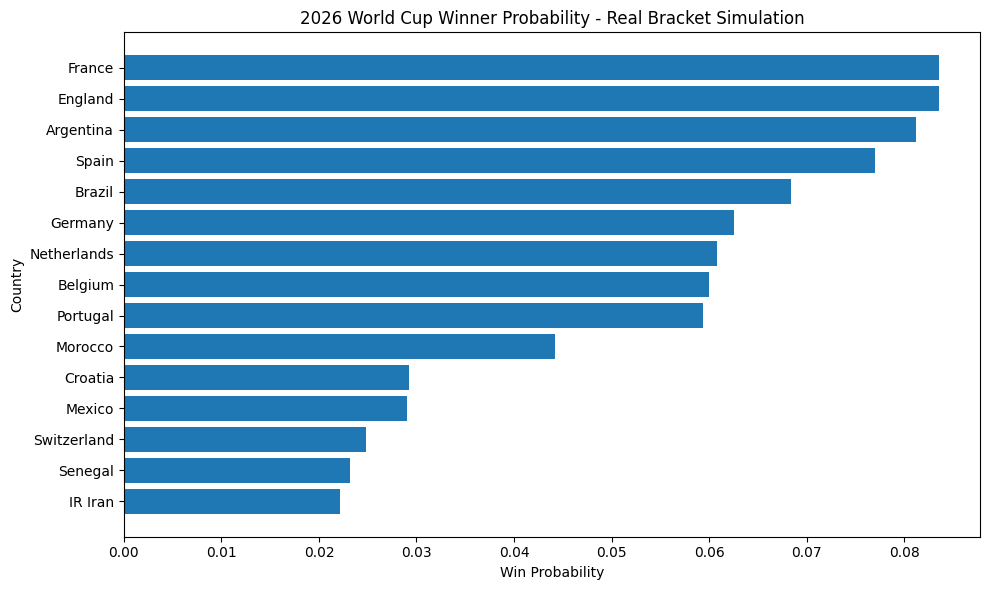

,country,titles,win_probability_percent
0,France,418,8.36
1,England,418,8.36
2,Argentina,406,8.12
3,Spain,385,7.70
4,Brazil,342,6.84
5,Germany,313,6.26
6,Netherlands,304,6.08
7,Belgium,300,6.00
8,Portugal,297,5.94
9,Morocco,221,4.42


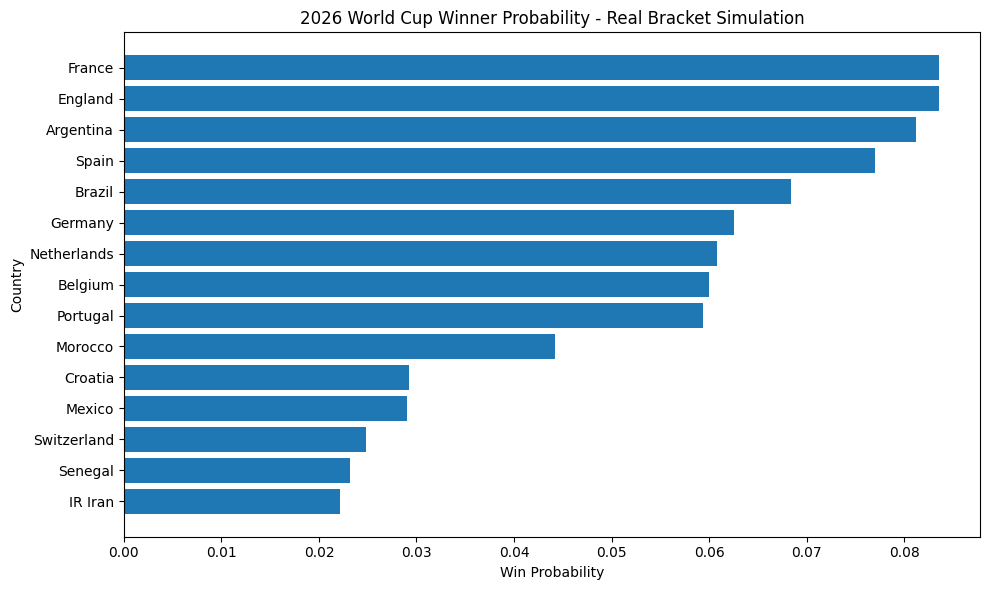

In [21]:
winner_probs.to_csv("/kaggle/working/world_cup_2026_winner_probabilities_real_bracket.csv", index=False)
stage_probs.to_csv("/kaggle/working/world_cup_2026_stage_probabilities_real_bracket.csv", index=False)
fixture_features_model.to_csv("/kaggle/working/group_fixture_predictions_2026.csv", index=False)
team_strength_2026.to_csv("/kaggle/working/team_strength_2026_calibrated.csv", index=False)
full_feature_df.to_csv("/kaggle/working/training_features_fifa_elo_form.csv", index=False)
trace_debug.to_csv("/kaggle/working/example_real_bracket_trace.csv", index=False)

top_winners = winner_probs.head(15).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_winners["country"], top_winners["win_probability"])
plt.gca().invert_yaxis()
plt.title("2026 World Cup Winner Probability - Real Bracket Simulation")
plt.xlabel("Win Probability")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(top_winners["country"], top_winners["win_probability"])
plt.gca().invert_yaxis()
plt.title("2026 World Cup Winner Probability - Real Bracket Simulation")
plt.xlabel("Win Probability")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("/kaggle/working/world_cup_2026_winner_probabilities_real_bracket.png", dpi=200)

winner_display = winner_probs.copy()
winner_display["win_probability_percent"] = (winner_display["win_probability"] * 100).round(2)
display(winner_display[["country", "titles", "win_probability_percent"]].head(15))

## 22. Final summary and sanity checks

In [22]:
top5 = set(winner_probs.head(5)["team_clean"])
expected_top_cluster = {"france", "spain", "argentina"}

model_summary = pd.DataFrame({
    "item": [
        "Training rows",
        "Features used",
        "Best model",
        "Selected model accuracy",
        "Tuned decision accuracy",
        "Elo used in training",
        "Elo pair coverage",
        "Real bracket used",
        "Annex C third-place mapping used",
        "Simulation runs",
        "Group fixtures",
        "Teams in fixtures",
        "Top predicted winner",
        "France/Spain/Argentina all in top 5?"
    ],
    "value": [
        len(full_feature_df),
        len(features),
        best_model_name,
        round(float(accuracy_score(y_test, preds)), 4),
        round(float(accuracy_score(y_test, best_preds)), 4),
        USE_ELO_IN_MAIN,
        round(float(elo_pair_coverage), 4),
        True,
        True,
        N_SIMULATIONS,
        len(fixture_features_model),
        len(set(fixture_features_model["home_team_clean"]) | set(fixture_features_model["away_team_clean"])),
        winner_probs.iloc[0]["country"],
        expected_top_cluster.issubset(top5)
    ]
})

display(model_summary)
model_summary.to_csv("/kaggle/working/model_summary_real_bracket.csv", index=False)

print("Top 10 winners:")
display(winner_display[["country", "titles", "win_probability_percent"]].head(10))

print("\\nKey team diagnostics:")
watch_teams = ["france", "spain", "argentina", "england", "brazil", "portugal", "germany", "netherlands", "belgium", "morocco", "iran", "switzerland"]
diagnostic_cols = [
    "country", "team_clean", "forecast_fifa_rank", "latest_elo", "adjusted_fifa_rank",
    "power_score", "current_tier_calibration", "fifa_rank_score", "elo_score",
    "weighted_squad_score", "weighted_attack_score", "recent_form_score_capped",
    "top_23_avg_overall", "player_data_coverage"
]
display(team_strength_2026[team_strength_2026["team_clean"].isin(watch_teams)][diagnostic_cols].sort_values("power_score", ascending=False))

print("\\nOutput files:")
for p in Path("/kaggle/working").glob("*"):
    print(p)

,item,value
0,Training rows,6992
1,Features used,42
2,Best model,RandomForest_tuned
3,Selected model accuracy,0.5518
4,Tuned decision accuracy,0.5804
5,Elo used in training,False
6,Elo pair coverage,0.0007
7,Real bracket used,True
8,Annex C third-place mapping used,True
9,Simulation runs,5000


Top 10 winners:


,country,titles,win_probability_percent
0,France,418,8.36
1,England,418,8.36
2,Argentina,406,8.12
3,Spain,385,7.70
4,Brazil,342,6.84
5,Germany,313,6.26
6,Netherlands,304,6.08
7,Belgium,300,6.00
8,Portugal,297,5.94
9,Morocco,221,4.42


\nKey team diagnostics:


,country,team_clean,forecast_fifa_rank,latest_elo,adjusted_fifa_rank,power_score,current_tier_calibration,fifa_rank_score,elo_score,weighted_squad_score,weighted_attack_score,recent_form_score_capped,top_23_avg_overall,player_data_coverage
17,England,england,4.0,2050.0,1.0,0.956781,0.018,0.979167,1.0,0.903284,0.833694,0.924946,82.260870,1.0000
18,France,france,1.0,2020.5,2.0,0.944820,0.040,1.000000,0.5,0.993252,0.862924,0.918280,84.000000,1.0000
40,Spain,spain,2.0,2020.5,3.0,0.938294,0.038,0.993056,0.5,1.000000,0.905329,0.876453,84.130435,1.0000
1,Argentina,argentina,3.0,2020.5,4.0,0.912148,0.036,0.986111,0.5,0.891334,0.832817,0.995139,81.956522,0.9615
6,Brazil,brazil,6.0,2020.5,5.0,0.895914,0.018,0.965278,0.5,0.957703,0.864611,0.794343,83.235294,0.6538
34,Portugal,portugal,5.0,2020.5,6.0,0.881448,0.018,0.972222,0.5,0.901035,0.856642,0.889701,82.217391,1.0000
19,Germany,germany,10.0,2020.5,7.0,0.856086,0.004,0.937500,0.5,0.928025,0.824009,0.881600,82.739130,1.0000
29,Netherlands,netherlands,7.0,2020.5,8.0,0.849641,0.006,0.958333,0.5,0.851338,0.812378,0.849495,81.173913,0.9615
4,Belgium,belgium,9.0,2020.5,10.0,0.793875,-0.006,0.944444,0.5,0.775111,0.705310,0.922588,79.652174,0.9615
22,IR Iran,iran,21.0,2020.5,12.0,0.786079,-0.018,0.861111,0.5,0.854248,0.866458,0.704533,78.000000,0.0385


\nOutput files:
/kaggle/working/model_summary_real_bracket.csv
/kaggle/working/world_cup_2026_stage_probabilities_real_bracket.csv
/kaggle/working/training_features_fifa_elo_form.csv
/kaggle/working/world_cup_2026_winner_probabilities_real_bracket.png
/kaggle/working/group_fixture_predictions_2026.csv
/kaggle/working/world_cup_2026_winner_probabilities_real_bracket.csv
/kaggle/working/__notebook__.ipynb
/kaggle/working/team_strength_2026_calibrated.csv
/kaggle/working/example_real_bracket_trace.csv
